In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PRED_DIR = "../outputs/models/predictions/"
PLOT_DIR = "../outputs/models/plots/comparisons/"
os.makedirs(PLOT_DIR, exist_ok=True)

MODELS = {
    "LR": "lr",
    "RF": "rf",
    "LSTM": "lstm",
    "GRU": "gru",
    "CNN-LSTM": "cnn_lstm",
    "Transformer": "transformer",
    "GNN": "gnn",
}

sns.set_style("whitegrid")


def load_preds(model_key, metric, split="test"):
    path = os.path.join(
        PRED_DIR, f"{model_key}_{metric}_{split}_predictions.csv"
    )
    df = pd.read_csv(path)
    return df["y_true"], df["y_pred"]


def plot_model_comparison_pred_vs_actual(
    metric,
    split="test",
    showImage=False
):
    plt.figure(figsize=(8, 8))

    all_true = []
    all_pred = []

    # Plot each model
    for name, key in MODELS.items():
        y_true, y_pred = load_preds(key, metric, split)

        sns.scatterplot(
            x=y_true,
            y=y_pred,
            alpha=0.55,
            label=name,
            s=40
        )

        all_true.append(y_true)
        all_pred.append(y_pred)

    # Global diagonal
    y_min = min([s.min() for s in all_true + all_pred])
    y_max = max([s.max() for s in all_true + all_pred])

    plt.plot(
        [y_min, y_max],
        [y_min, y_max],
        "k--",
        linewidth=2,
        label="Ideal"
    )

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{metric} – Predicted vs Actual (Model Comparison, {split.capitalize()})")
    plt.legend()
    plt.tight_layout()

    out = os.path.join(
        PLOT_DIR, f"compare_{metric.lower()}_{split}_pred_vs_actual.png"
    )
    plt.savefig(out, dpi=300)
    print(f"Saved → {out}")

    if showImage:
        plt.show()
    else:
        plt.close()


Saved → ../outputs/models/plots/comparisons/compare_throughput_test_pred_vs_actual.png


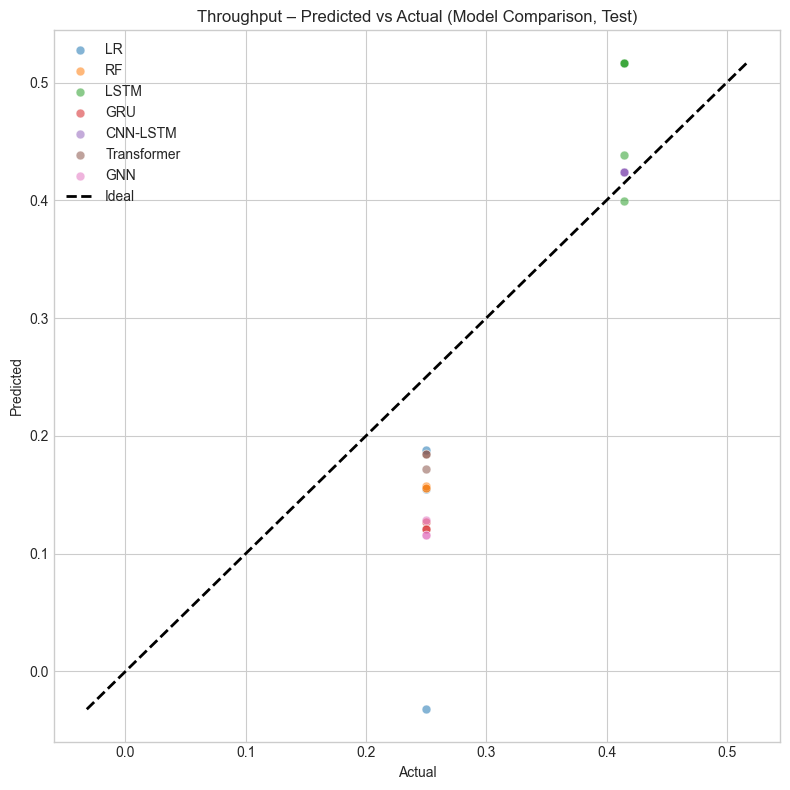

In [22]:
plot_model_comparison_pred_vs_actual(
    metric="Throughput",
    split="test",
    showImage=True
)

Saved → ../outputs/models/plots/comparisons/compare_latency_test_pred_vs_actual.png


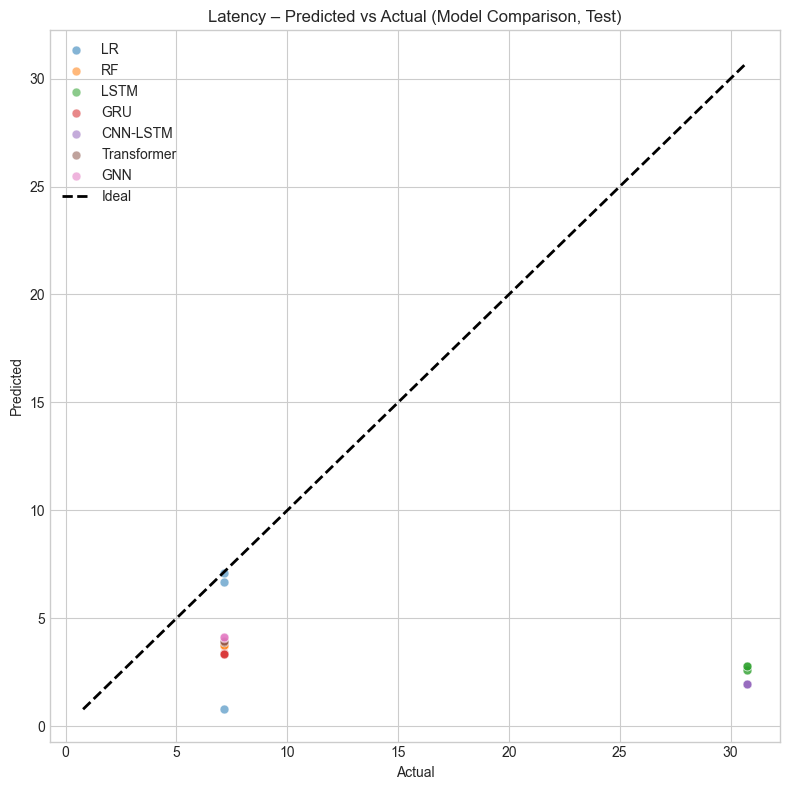

In [23]:
plot_model_comparison_pred_vs_actual(
    metric="Latency",
    split="test",
    showImage=True
)

Saved → ../outputs/models/plots/comparisons/compare_loss_test_pred_vs_actual.png


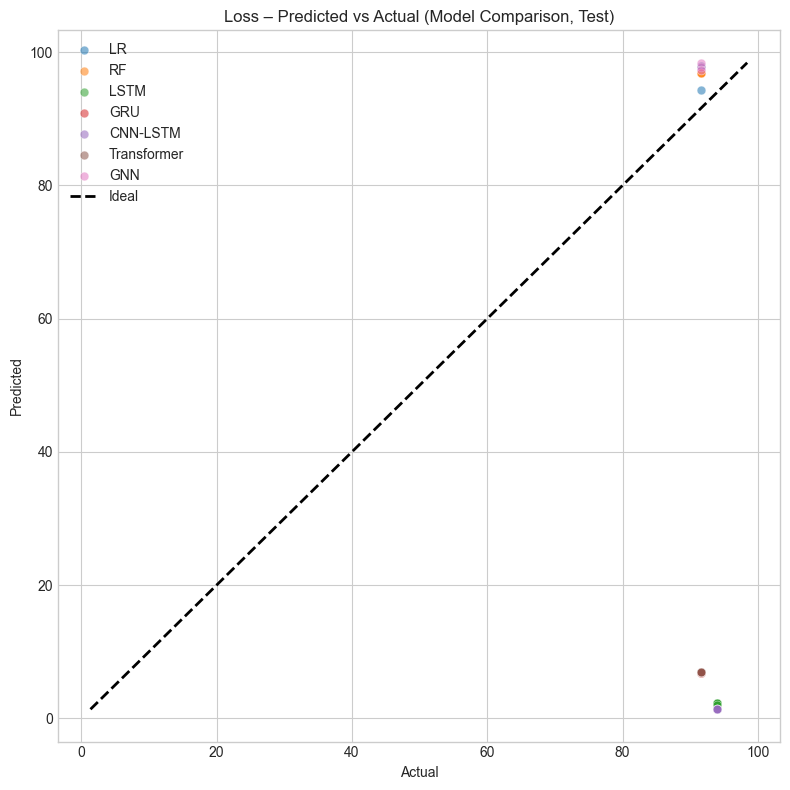

In [24]:
plot_model_comparison_pred_vs_actual(
    metric="Loss",
    split="test",
    showImage=True
)

In [25]:
import os
import pandas as pd
import matplotlib.pyplot as plt

PRED_DIR = "../outputs/models/predictions/"
PLOT_DIR = "../outputs/models/plots/comparisons/"
os.makedirs(PLOT_DIR, exist_ok=True)

# Model → (file_key, color, linestyle)
MODELS = {
    "LR":          ("lr",          "#1f77b4", ":"),    # blue, dotted
    "RF":          ("rf",          "#ff7f0e", "-."),   # orange, dash-dot
    "LSTM":        ("lstm",        "#2ca02c", "--"),   # green, dashed
    "GRU":         ("gru",         "#d62728", "--"),   # red, dashed
    "CNN-LSTM":    ("cnn_lstm",    "#9467bd", "-"),    # purple, solid
    "Transformer": ("transformer", "#8c564b", (0, (5, 2))),  # brown, long-dash
    "GNN":         ("gnn",         "#e377c2", (0, (3, 1, 1, 1))),  # pink, custom
}

plt.style.use("seaborn-v0_8-whitegrid")


def load_preds(model_key, metric, split="test"):
    path = os.path.join(
        PRED_DIR, f"{model_key}_{metric}_{split}_predictions.csv"
    )
    df = pd.read_csv(path)
    return df["y_true"], df["y_pred"]


def plot_model_comparison_time_series(
    metric,
    split="test",
    max_points=300,
    showImage=False
):
    plt.figure(figsize=(13, 6))

    # -------------------------------------------------
    # Ground truth
    # -------------------------------------------------
    first_key = next(iter(MODELS.values()))[0]
    y_true, _ = load_preds(first_key, metric, split)
    y_true = y_true.iloc[:max_points]

    plt.plot(
        y_true.values,
        label="Actual",
        color="black",
        linewidth=3.5,
        linestyle="-"
    )

    # -------------------------------------------------
    # Model predictions
    # -------------------------------------------------
    for model_name, (key, color, style) in MODELS.items():
        _, y_pred = load_preds(key, metric, split)
        y_pred = y_pred.iloc[:max_points]

        plt.plot(
            y_pred.values,
            label=model_name,
            color=color,
            linestyle=style,
            linewidth=2
        )

    plt.title(
        f"{metric} – Time Series Comparison ({split.capitalize()})",
        fontsize=13
    )
    plt.xlabel("Time Index")
    plt.ylabel(metric)

    # -------------------------------------------------
    # Legend BELOW the plot
    # -------------------------------------------------
    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=4,
        frameon=True,
        fontsize=9
    )

    # Extra bottom space for legend
    plt.tight_layout(rect=[0, 0.08, 1, 1])

    out = os.path.join(
        PLOT_DIR,
        f"compare_{metric.lower()}_{split}_time_series.png"
    )
    plt.savefig(out, dpi=300)
    print(f"Saved → {out}")

    if showImage:
        plt.show()
    else:
        plt.close()


Saved → ../outputs/models/plots/comparisons/compare_throughput_test_time_series.png


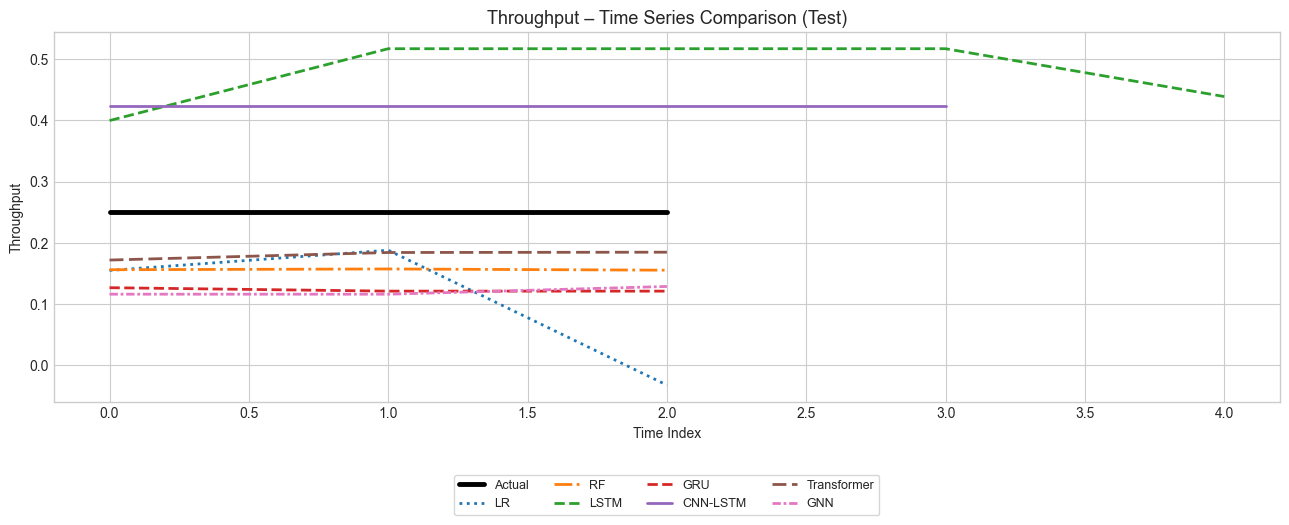

In [26]:
plot_model_comparison_time_series(
    metric="Throughput",
    split="test",
    max_points=300,
    showImage=True
)

Saved → ../outputs/models/plots/comparisons/compare_latency_test_time_series.png


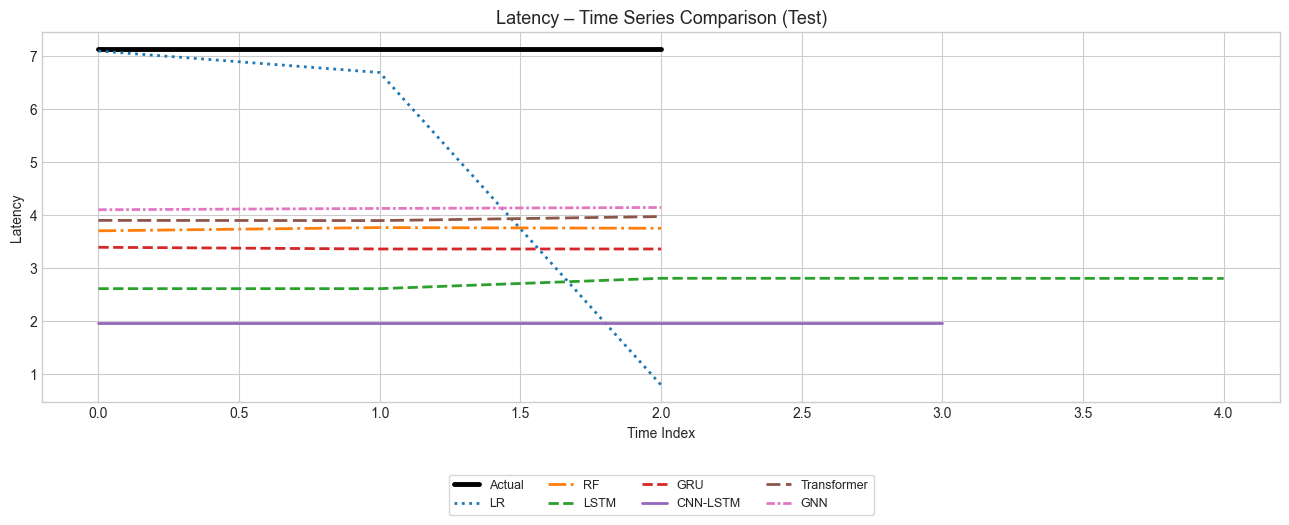

In [27]:
plot_model_comparison_time_series(
    metric="Latency",
    split="test",
    showImage=True
)

Saved → ../outputs/models/plots/comparisons/compare_loss_test_time_series.png


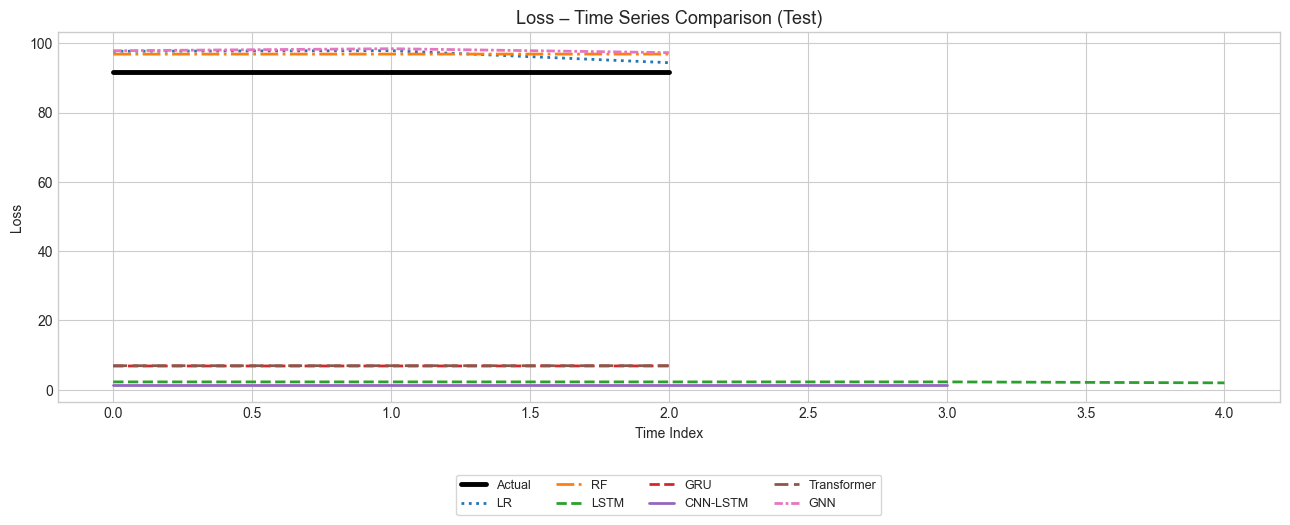

In [28]:
plot_model_comparison_time_series(
    metric="Loss",
    split="test",
    showImage=True
)

In [29]:
import os
import pandas as pd


from edge_evaluations.lr_edge_evaluation import evaluate_lr_edge
from edge_evaluations.rf_edge_evalutaion import  evaluate_rf_edge
from edge_evaluations.xgb_edge_evaluation import evaluate_xgb_edge
from edge_evaluations.mlp_edge_evaluation import evaluate_mlp_edge
from edge_evaluations.lstm_edge_evaluation import evaluate_lstm_edge
from edge_evaluations.gru_edge_evaluation import evaluate_gru_edge
from edge_evaluations.bilstm_edge_evaluation import evaluate_bilstm_edge
from edge_evaluations.transformer_edge_evaluation import evaluate_transformer_edge
from edge_evaluations.cnn_lstm_edge_evaluation import evaluate_cnn_lstm_edge
from edge_evaluations.gnn_edge_evaluation import evaluate_gnn_edge

from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

In [30]:

# import warnings
# warnings.filterwarnings("ignore", message="X does not have valid feature names")

# METRIC_SUFFIX = {
#     "Throughput": "throughput",
#     "Latency": "latency",
#     "Loss": "loss",
# }


# def run_all_edge_metrics(metric="Throughput", input_dim=103):

#     assert metric in ["Throughput", "Latency", "Loss"], \
#         f"Invalid metric: {metric}"

#     metric_key = METRIC_SUFFIX[metric]

#     # -----------------------------
#     # Load feature names (for XGB)
#     # -----------------------------
#     df_train = pd.read_csv("../outputs/datasets/train.csv")
#     feature_cols = [
#         c for c in df_train.columns
#         if c not in [
#             "Perf_Avg_Throughput", "Perf_Avg_Latency", "Perf_Avg_Loss",
#             "StartDateTime", "EndDateTime", "Perf_Filename",
#             "ND_Filename", "RunDateTime"
#         ]
#     ]

#     # -----------------------------
#     # Define models + paths
#     # -----------------------------
#     edge_jobs = {

#         "LR": lambda: evaluate_lr_edge(
#             model_path=f"../outputs/models/lr_model_{metric_key}.pkl",
#             scaler_path="../outputs/models/lr_scaler.pkl",
#             input_dim=input_dim
#         ),

#         "RF": lambda: evaluate_rf_edge(
#             model_path=f"../outputs/models/rf_model_{metric_key}.pkl",
#             X_sample=np.random.randn(1, input_dim)
#         ),

#         "XGB": lambda: evaluate_xgb_edge(
#             model_path=f"../outputs/models/xgb_model_{metric_key}.json",
#             X_sample=pd.DataFrame(
#                 [np.random.randn(len(feature_cols))],
#                 columns=feature_cols
#             )
#         ),

#         "MLP": lambda: evaluate_mlp_edge(
#             model_path=f"../outputs/models/mlp_model_{metric_key}.pt",
#             input_dim=input_dim
#         ),

#         "LSTM": lambda: evaluate_lstm_edge(
#             model_path=f"../outputs/models/lstm_model_{metric_key}.pt",
#             input_dim=input_dim
#         ),

#         "GRU": lambda: evaluate_gru_edge(
#             model_path=f"../outputs/models/gru_model_{metric_key}.pt",
#             input_dim=input_dim
#         ),

#         "BiLSTM": lambda: evaluate_bilstm_edge(
#             model_path=f"../outputs/models/bilstm_model_{metric_key}.pt",
#             input_dim=input_dim
#         ),

#         "Transformer": lambda: evaluate_transformer_edge(
#             model_path=f"../outputs/models/transformer_model_{metric_key}.pt",
#             input_dim=input_dim
#         ),

#         "CNN-LSTM": lambda: evaluate_cnn_lstm_edge(
#             model_path=f"../outputs/models/cnn_lstm_model_{metric_key}.pt",
#             input_dim=input_dim
#         ),

#         "GNN": lambda: evaluate_gnn_edge(
#             model_path=f"../outputs/models/gnn_model_{metric_key}.pt",
#             input_dim=3,
#             num_nodes=10
#         ),
#     }

#     # -----------------------------
#     # Run models with tqdm
#     # -----------------------------
#     print(f"\n========== Running Unified Edge Evaluation ({metric}) ==========\n")

#     results = {}
#     pbar = tqdm(edge_jobs.items(), total=len(edge_jobs), unit="model")

#     for model_name, eval_fn in pbar:
#         pbar.set_description(f"Evaluating {model_name}")
#         results[model_name] = eval_fn()

#     # -----------------------------
#     # Save results
#     # -----------------------------
#     df = pd.DataFrame(results).T

#     out_dir = "../outputs/edge_analysis/"
#     os.makedirs(out_dir, exist_ok=True)

#     out_path = os.path.join(
#         out_dir,
#         f"{metric_key}_edge_metrics.csv"
#     )
#     df.to_csv(out_path)

#     print(f"\nSaved unified edge evaluation → {out_path}")
#     return df


In [31]:
import os
import warnings
import numpy as np
import pandas as pd
from tqdm import tqdm

warnings.filterwarnings("ignore", message="X does not have valid feature names")

# --------------------------------------------------
# Fixed feature dimensionality (after feature selection)
# --------------------------------------------------
FIXED_INPUT_DIM = 73

METRIC_SUFFIX = {
    "Throughput": "throughput",
    "Latency": "latency",
    "Loss": "loss",
}


def run_all_edge_metrics(metric="Throughput"):
    """
    Unified edge-efficiency evaluation for all models
    using a fixed 73-feature input space.
    """

    assert metric in METRIC_SUFFIX, f"Invalid metric: {metric}"
    metric_key = METRIC_SUFFIX[metric]

    # --------------------------------------------------
    # Load feature names (needed for XGBoost)
    # --------------------------------------------------
    df_train = pd.read_csv("../outputs/datasets/train.csv")

    feature_cols = [
        c for c in df_train.columns
        if c not in [
            "Perf_Avg_Throughput",
            "Perf_Avg_Latency",
            "Perf_Avg_Loss",
            "StartDateTime",
            "EndDateTime",
            "Perf_Filename",
            "ND_Filename",
            "RunDateTime",
        ]
    ]

    # Enforce 73 features explicitly
    feature_cols = feature_cols[:FIXED_INPUT_DIM]

    # --------------------------------------------------
    # Define unified edge evaluation jobs
    # --------------------------------------------------
    edge_jobs = {

    # -----------------------------
    # Linear Regression (fixed-dim)
    # -----------------------------
    "LR": lambda: evaluate_lr_edge(
        model_path=f"../outputs/models/lr_model_{metric_key}.pkl",
        scaler_path="../outputs/models/lr_scaler.pkl",
        input_dim=FIXED_INPUT_DIM
    ),

    # -----------------------------
    # Random Forest
    # -----------------------------
    "RF": lambda: evaluate_rf_edge(
        model_path=f"../outputs/models/rf_model_{metric_key}.pkl",
        X_sample=np.random.randn(1, FIXED_INPUT_DIM)
    ),

    # -----------------------------
    # XGBoost
    # -----------------------------
    "XGB": lambda: evaluate_xgb_edge(
        model_path=f"../outputs/models/xgb_model_{metric_key}.json",
        X_sample=pd.DataFrame(
            [np.random.randn(FIXED_INPUT_DIM)],
            columns=feature_cols
        )
    ),

    # -----------------------------
    # Neural models (AUTO input_dim)
    # -----------------------------
    "MLP": lambda: evaluate_mlp_edge(
        model_path=f"../outputs/models/mlp_model_{metric_key}.pt"
    ),

    "LSTM": lambda: evaluate_lstm_edge(
        model_path=f"../outputs/models/lstm_model_{metric_key}.pt"
    ),

    "GRU": lambda: evaluate_gru_edge(
        model_path=f"../outputs/models/gru_model_{metric_key}.pt"
    ),

    "BiLSTM": lambda: evaluate_bilstm_edge(
        model_path=f"../outputs/models/bilstm_model_{metric_key}.pt"
    ),

    "Transformer": lambda: evaluate_transformer_edge(
        model_path=f"../outputs/models/transformer_model_{metric_key}.pt"
    ),

    "CNN-LSTM": lambda: evaluate_cnn_lstm_edge(
        model_path=f"../outputs/models/cnn_lstm_model_{metric_key}.pt"
    ),

    # -----------------------------
    # Graph Neural Network
    # -----------------------------
    "GNN": lambda: evaluate_gnn_edge(
        model_path=f"../outputs/models/gnn_model_{metric_key}.pt",
        input_dim=3,
        num_nodes=10
    ),
}


    # --------------------------------------------------
    # Run unified evaluation
    # --------------------------------------------------
    print(f"\n========== Running Unified Edge Evaluation ({metric}) ==========\n")

    results = {}
    pbar = tqdm(edge_jobs.items(), total=len(edge_jobs), unit="model")

    for model_name, eval_fn in pbar:
        pbar.set_description(f"Evaluating {model_name}")
        results[model_name] = eval_fn()

    # --------------------------------------------------
    # Save results
    # --------------------------------------------------
    df = pd.DataFrame(results).T

    out_dir = "../outputs/edge_analysis/"
    os.makedirs(out_dir, exist_ok=True)

    out_path = os.path.join(
        out_dir,
        f"{metric_key}_edge_metrics.csv"
    )

    df.to_csv(out_path)

    print(f"\nSaved unified edge evaluation → {out_path}")
    return df


In [32]:
run_all_edge_metrics(metric="Throughput")


========== Running Unified Edge Evaluation (Throughput) ==========



Evaluating GNN: 100%|██████████| 10/10 [00:13<00:00,  1.31s/model]       


Saved unified edge evaluation → ../outputs/edge_analysis/throughput_edge_metrics.csv


,Parameters,Model Size (Bytes),Model Size (MB),FLOPs,Latency (s),Latency (ms),Energy Estimated (J),Peak Activation Memory (Bytes),Model Path,Trees,Total Nodes,Average Nodes per Tree,Average Tree Depth,Max Tree Depth,Input Dim,Estimated Energy (J),Num Nodes,Node Feature Dim,Hidden Dim
LR,74,296,0.000282,146,0.000025,0.024513,0.0,4,../outputs/models/lr_model_throughput.pkl,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RF,NaN,204161,0.194703,NaN,0.055742,55.742058,0.111484,584,../outputs/models/rf_model_throughput.pkl,300,1500,5.0,2.0,2,NaN,NaN,NaN,NaN,NaN
XGB,NaN,196385,0.187287,NaN,0.000385,0.385381,0.000771,584,../outputs/models/xgb_model_throughput.json,400,912,2.28,0.625,4,NaN,NaN,NaN,NaN,NaN
MLP,21633,86532,0.082523,42880,0.000177,0.176796,0.000354,4,../outputs/models/mlp_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,103,NaN,NaN,NaN,NaN
LSTM,76609,306436,0.29224,86144,0.000484,0.484178,0.000968,4,../outputs/models/lstm_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,103,NaN,NaN,NaN,NaN
GRU,51713,206852,0.197269,53120,0.000205,0.205193,0.00041,4,../outputs/models/gru_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,73,NaN,NaN,NaN,NaN
BiLSTM,170625,682500,0.650883,141568,0.000513,0.512561,0.001025,4,../outputs/models/bilstm_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,73,NaN,NaN,NaN,NaN
Transformer,406145,1624580,1.54932,393728,0.000422,0.422172,NaN,4,../outputs/models/transformer_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,73,0.000844,NaN,NaN,NaN
CNN-LSTM,53185,NaN,0.202885,106370,NaN,0.430555,0.000861,4120,../outputs/models/cnn_lstm_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,103,NaN,NaN,NaN,NaN
GNN,1217,4868,0.004642,NaN,0.000694,0.693521,NaN,120,../outputs/models/gnn_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,NaN,0.003468,10,3,32


In [33]:
run_all_edge_metrics(metric="Latency")


========== Running Unified Edge Evaluation (Latency) ==========



Evaluating GNN: 100%|██████████| 10/10 [00:12<00:00,  1.29s/model]       


Saved unified edge evaluation → ../outputs/edge_analysis/latency_edge_metrics.csv


,Parameters,Model Size (Bytes),Model Size (MB),FLOPs,Latency (s),Latency (ms),Energy Estimated (J),Peak Activation Memory (Bytes),Model Path,Trees,Total Nodes,Average Nodes per Tree,Average Tree Depth,Max Tree Depth,Input Dim,Estimated Energy (J),Num Nodes,Node Feature Dim,Hidden Dim
LR,74,296,0.000282,146,0.000016,0.016471,0.0,4,../outputs/models/lr_model_latency.pkl,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RF,NaN,223313,0.212968,NaN,0.051414,51.414001,0.102828,584,../outputs/models/rf_model_latency.pkl,300,1766,5.886667,2.373333,3,NaN,NaN,NaN,NaN,NaN
XGB,NaN,246483,0.235065,NaN,0.000182,0.182134,0.000364,584,../outputs/models/xgb_model_latency.json,400,1916,4.79,1.7575,4,NaN,NaN,NaN,NaN,NaN
MLP,21633,86532,0.082523,42880,0.000066,0.065858,0.000132,4,../outputs/models/mlp_model_latency.pt,NaN,NaN,NaN,NaN,NaN,103,NaN,NaN,NaN,NaN
LSTM,76609,306436,0.29224,86144,0.000311,0.310661,0.000621,4,../outputs/models/lstm_model_latency.pt,NaN,NaN,NaN,NaN,NaN,103,NaN,NaN,NaN,NaN
GRU,51713,206852,0.197269,53120,0.000186,0.186465,0.000373,4,../outputs/models/gru_model_latency.pt,NaN,NaN,NaN,NaN,NaN,73,NaN,NaN,NaN,NaN
BiLSTM,170625,682500,0.650883,141568,0.000533,0.532998,0.001066,4,../outputs/models/bilstm_model_latency.pt,NaN,NaN,NaN,NaN,NaN,73,NaN,NaN,NaN,NaN
Transformer,406145,1624580,1.54932,393728,0.000442,0.441553,NaN,4,../outputs/models/transformer_model_latency.pt,NaN,NaN,NaN,NaN,NaN,73,0.000883,NaN,NaN,NaN
CNN-LSTM,53185,NaN,0.202885,106370,NaN,0.423471,0.000847,4120,../outputs/models/cnn_lstm_model_latency.pt,NaN,NaN,NaN,NaN,NaN,103,NaN,NaN,NaN,NaN
GNN,1217,4868,0.004642,NaN,0.000696,0.696391,NaN,120,../outputs/models/gnn_model_latency.pt,NaN,NaN,NaN,NaN,NaN,NaN,0.003482,10,3,32


In [34]:
run_all_edge_metrics(metric="Loss")


========== Running Unified Edge Evaluation (Loss) ==========



Evaluating GNN: 100%|██████████| 10/10 [00:13<00:00,  1.33s/model]       


Saved unified edge evaluation → ../outputs/edge_analysis/loss_edge_metrics.csv


,Parameters,Model Size (Bytes),Model Size (MB),FLOPs,Latency (s),Latency (ms),Energy Estimated (J),Peak Activation Memory (Bytes),Model Path,Trees,Total Nodes,Average Nodes per Tree,Average Tree Depth,Max Tree Depth,Input Dim,Estimated Energy (J),Num Nodes,Node Feature Dim,Hidden Dim
LR,74,296,0.000282,146,0.000009,0.008514,0.0,4,../outputs/models/lr_model_loss.pkl,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RF,NaN,221297,0.211045,NaN,0.056424,56.423753,0.112848,584,../outputs/models/rf_model_loss.pkl,300,1738,5.793333,2.346667,4,NaN,NaN,NaN,NaN,NaN
XGB,NaN,231818,0.221079,NaN,0.000169,0.168729,0.000337,584,../outputs/models/xgb_model_loss.json,400,1628,4.07,1.4375,4,NaN,NaN,NaN,NaN,NaN
MLP,21633,86532,0.082523,42880,0.000059,0.058893,0.000118,4,../outputs/models/mlp_model_loss.pt,NaN,NaN,NaN,NaN,NaN,103,NaN,NaN,NaN,NaN
LSTM,76609,306436,0.29224,86144,0.000287,0.287151,0.000574,4,../outputs/models/lstm_model_loss.pt,NaN,NaN,NaN,NaN,NaN,103,NaN,NaN,NaN,NaN
GRU,51713,206852,0.197269,53120,0.000198,0.19786,0.000396,4,../outputs/models/gru_model_loss.pt,NaN,NaN,NaN,NaN,NaN,73,NaN,NaN,NaN,NaN
BiLSTM,170625,682500,0.650883,141568,0.000538,0.538426,0.001077,4,../outputs/models/bilstm_model_loss.pt,NaN,NaN,NaN,NaN,NaN,73,NaN,NaN,NaN,NaN
Transformer,406145,1624580,1.54932,393728,0.000441,0.441023,NaN,4,../outputs/models/transformer_model_loss.pt,NaN,NaN,NaN,NaN,NaN,73,0.000882,NaN,NaN,NaN
CNN-LSTM,53185,NaN,0.202885,106370,NaN,0.414976,0.00083,4120,../outputs/models/cnn_lstm_model_loss.pt,NaN,NaN,NaN,NaN,NaN,103,NaN,NaN,NaN,NaN
GNN,1217,4868,0.004642,NaN,0.000718,0.718335,NaN,120,../outputs/models/gnn_model_loss.pt,NaN,NaN,NaN,NaN,NaN,NaN,0.003592,10,3,32


In [35]:
df=pd.read_csv("../outputs/edge_analysis/throughput_edge_metrics.csv", index_col=0)
df.head(10)

,Parameters,Model Size (Bytes),Model Size (MB),FLOPs,Latency (s),Latency (ms),Energy Estimated (J),Peak Activation Memory (Bytes),Model Path,Trees,Total Nodes,Average Nodes per Tree,Average Tree Depth,Max Tree Depth,Input Dim,Estimated Energy (J),Num Nodes,Node Feature Dim,Hidden Dim
LR,74.0,296.0,0.000282,146.0,0.000025,0.024513,7.300000e-08,4,../outputs/models/lr_model_throughput.pkl,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RF,NaN,204161.0,0.194703,NaN,0.055742,55.742058,1.114841e-01,584,../outputs/models/rf_model_throughput.pkl,300.0,1500.0,5.00,2.000,2.0,NaN,NaN,NaN,NaN,NaN
XGB,NaN,196385.0,0.187287,NaN,0.000385,0.385381,7.707628e-04,584,../outputs/models/xgb_model_throughput.json,400.0,912.0,2.28,0.625,4.0,NaN,NaN,NaN,NaN,NaN
MLP,21633.0,86532.0,0.082523,42880.0,0.000177,0.176796,3.535921e-04,4,../outputs/models/mlp_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,103.0,NaN,NaN,NaN,NaN
LSTM,76609.0,306436.0,0.292240,86144.0,0.000484,0.484178,9.683553e-04,4,../outputs/models/lstm_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,103.0,NaN,NaN,NaN,NaN
GRU,51713.0,206852.0,0.197269,53120.0,0.000205,0.205193,4.103861e-04,4,../outputs/models/gru_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN
BiLSTM,170625.0,682500.0,0.650883,141568.0,0.000513,0.512561,1.025123e-03,4,../outputs/models/bilstm_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN
Transformer,406145.0,1624580.0,1.549320,393728.0,0.000422,0.422172,NaN,4,../outputs/models/transformer_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,73.0,0.000844,NaN,NaN,NaN
CNN-LSTM,53185.0,NaN,0.202885,106370.0,NaN,0.430555,8.611104e-04,4120,../outputs/models/cnn_lstm_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,103.0,NaN,NaN,NaN,NaN
GNN,1217.0,4868.0,0.004642,NaN,0.000694,0.693521,NaN,120,../outputs/models/gnn_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,NaN,0.003468,10.0,3.0,32.0


In [36]:
df.describe()

,Parameters,Model Size (Bytes),Model Size (MB),FLOPs,Latency (s),Latency (ms),Energy Estimated (J),Peak Activation Memory (Bytes),Trees,Total Nodes,Average Nodes per Tree,Average Tree Depth,Max Tree Depth,Input Dim,Estimated Energy (J),Num Nodes,Node Feature Dim,Hidden Dim
count,8.000000,9.000000e+00,10.000000,7.000000,9.000000,10.000000,8.000000e+00,10.000000,2.000000,2.000000,2.00000,2.000000,2.000000,6.000000,2.000000,1.0,1.0,1.0
mean,97650.125000,3.680678e+05,0.336204,117708.000000,0.006516,5.907693,1.448419e-02,543.200000,350.000000,1206.000000,3.64000,1.312500,3.000000,88.000000,0.002156,10.0,3.0,32.0
std,136079.581274,5.135967e+05,0.464161,130046.683613,0.018461,17.511053,3.919547e-02,1278.903419,70.710678,415.778787,1.92333,0.972272,1.414214,16.431677,0.001855,NaN,NaN,NaN
min,74.000000,2.960000e+02,0.000282,146.000000,0.000025,0.024513,7.300000e-08,4.000000,300.000000,912.000000,2.28000,0.625000,2.000000,73.000000,0.000844,10.0,3.0,32.0
25%,16529.000000,8.653200e+04,0.108714,48000.000000,0.000205,0.250240,3.961876e-04,4.000000,325.000000,1059.000000,2.96000,0.968750,2.500000,73.000000,0.001500,10.0,3.0,32.0
50%,52449.000000,2.041610e+05,0.195986,86144.000000,0.000422,0.426363,8.159366e-04,4.000000,350.000000,1206.000000,3.64000,1.312500,3.000000,88.000000,0.002156,10.0,3.0,32.0
75%,100113.000000,3.064360e+05,0.269901,123969.000000,0.000513,0.505465,9.825471e-04,468.000000,375.000000,1353.000000,4.32000,1.656250,3.500000,103.000000,0.002812,10.0,3.0,32.0
max,406145.000000,1.624580e+06,1.549320,393728.000000,0.055742,55.742058,1.114841e-01,4120.000000,400.000000,1500.000000,5.00000,2.000000,4.000000,103.000000,0.003468,10.0,3.0,32.0


In [37]:
print(df.columns.tolist())


['Parameters', 'Model Size (Bytes)', 'Model Size (MB)', 'FLOPs', 'Latency (s)', 'Latency (ms)', 'Energy Estimated (J)', 'Peak Activation Memory (Bytes)', 'Model Path', 'Trees', 'Total Nodes', 'Average Nodes per Tree', 'Average Tree Depth', 'Max Tree Depth', 'Input Dim', 'Estimated Energy (J)', 'Num Nodes', 'Node Feature Dim', 'Hidden Dim']


In [38]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

METRIC_SUFFIX = {
    "Throughput": "throughput",
    "Latency": "latency",
    "Loss": "loss",
}


def load_metrics(metric="Throughput"):
    assert metric in METRIC_SUFFIX, f"Invalid metric: {metric}"

    metric_key = METRIC_SUFFIX[metric]
    csv_path = f"../outputs/edge_analysis/{metric_key}_edge_metrics.csv"

    df = pd.read_csv(csv_path, index_col=0)

    # Validate required columns
    required = [
        "Model Size (MB)",
        "Latency (ms)",
        "Energy Estimated (J)",
        "FLOPs",
    ]

    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(
            f"Missing required columns: {missing}\n"
            f"Available: {df.columns.tolist()}"
        )

    return df


def plot_modelsize(df, save_dir,metric="Throughput",showImage=False):
    plt.figure(figsize=(10, 6))

    plt.bar(df.index, df["Model Size (MB)"], alpha=0.6, label="Model Size (MB)")
    # plt.plot(df.index, df["Latency (ms)"], color="red", marker="o", linewidth=2, label="Latency (ms)")

    plt.title(f"{metric} – Model Size Comparison")
    plt.xlabel("Model")
    plt.ylabel("Value")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()

    path = os.path.join(save_dir, "modelsize.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    if showImage:
        plt.show()
    plt.close()

def plot_size_vs_latency(df, save_dir,metric="Throughput",showImage=False):
    plt.figure(figsize=(10, 6))

    plt.bar(df.index, df["Model Size (MB)"], alpha=0.6, label="Model Size (MB)")
    plt.plot(df.index, df["Latency (ms)"], color="red", marker="o", linewidth=2, label="Latency (ms)")

    plt.title(f"{metric} – Model Size vs Inference Latency")
    plt.xlabel("Model")
    plt.ylabel("Value")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()

    path = os.path.join(save_dir, "size_vs_latency.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    if showImage:
        plt.show()
    plt.close()


def plot_latency(df, save_dir,metric="Throughput",showImage=False):
    plt.figure(figsize=(10, 6))

    # plt.bar(df.index, df["Model Size (MB)"], alpha=0.6, label="Model Size (MB)")
    plt.plot(df.index, df["Latency (ms)"],  color="red", marker="o", linewidth=2, label="Latency (ms)")

    plt.title(f"{metric} – Inference Latency")
    plt.xlabel("Model")
    plt.ylabel("Value")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()

    path = os.path.join(save_dir, "inference_latency.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    if showImage:
        plt.show()
    plt.close()

def plot_energy(df, save_dir,metric="Throughput", showImage=False):
    plt.figure(figsize=(10, 6))

    plt.bar(df.index, df["Energy Estimated (J)"], color="orange", alpha=0.7)

    plt.title("Energy per Inference (J)")
    plt.xlabel("Model")
    plt.ylabel("Energy (J)")
    plt.grid(True, linestyle="--", alpha=0.4)

    path = os.path.join(save_dir, "energy_per_inference.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    if showImage:
        plt.show()
    plt.close()



def plot_flops(df, save_dir,metric="Throughput",showImage=False):
    plt.figure(figsize=(10, 6))

    plt.bar(df.index, df["FLOPs"], color="green", alpha=0.7)

    plt.title(f"{metric} – Model FLOPs per Inference")
    plt.xlabel("Model")
    plt.ylabel("FLOPs")
    plt.grid(True, linestyle="--", alpha=0.4)

    path = os.path.join(save_dir, "flops_comparison.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    if showImage:
        plt.show()
    plt.close()



def plot_radar(df, save_dir,metric="Throughput", showImage=False):

    metrics = ["Model Size (MB)", "Latency (ms)", "Energy Estimated (J)", "FLOPs"]
    labels = df.index.tolist()

    # normalization 0-1
    norm_df = (df[metrics] - df[metrics].min()) / (df[metrics].max() - df[metrics].min())

    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)

    for model in labels:
        values = norm_df.loc[model].tolist()
        values += values[:1]

        ax.plot(angles, values, linewidth=2, label=model)
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)
    plt.title(f"{metric} – Normalized Model Comparison (Radar Chart)")
    plt.legend(bbox_to_anchor=(1.2, 1.1))

    path = os.path.join(save_dir, "radar_comparison.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    if showImage:
        plt.show()
    plt.close()


def plot_latency_energy(df, save_dir,metric="Throughput", showImage=False):
    plt.figure(figsize=(10, 6))

    x = df["Latency (ms)"]
    y = df["Energy Estimated (J)"]
    sizes = df["Model Size (MB)"] * 25

    plt.scatter(x, y, s=sizes, alpha=0.75)

    for model in df.index:
        plt.annotate(
            model,
            (x[model], y[model]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

    # -------------------------------
    # Log scaling (key improvement)
    # -------------------------------
    plt.xscale("log")
    plt.yscale("log")

    plt.title(f"{metric} – Latency vs Energy per Inference (Bubble = Model Size)")
    plt.xlabel("Latency (ms, log scale)")
    plt.ylabel("Energy per Inference (J, log scale)")
    plt.grid(True, which="both", linestyle="--", alpha=0.4)

    path = os.path.join(save_dir, "latency_vs_energy_log.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")

    if showImage:
        plt.show()
    plt.close()

def plot_latency_energy_barline(
    df,
    save_dir,
    metric_name="Throughput",
    showImage=False
):
    import numpy as np

    models = df.index.tolist()
    x = np.arange(len(models))

    latency = df["Latency (ms)"]
    energy  = df["Energy Estimated (J)"]

    # -----------------------------
    # Identify best model (edge-efficient)
    # -----------------------------
    best_model = (
        df.sort_values(
            by=["Latency (ms)", "Energy Estimated (J)"],
            ascending=[True, True]
        )
        .index[0]
    )
    best_idx = models.index(best_model)

    # -----------------------------
    # Plot
    # -----------------------------
    fig, ax1 = plt.subplots(figsize=(11, 6))

    # Latency bars
    bars = ax1.bar(
        x,
        latency,
        width=0.6,
        color="#4C72B0",
        alpha=0.8,
        label="Latency (ms)"
    )

    # Highlight best latency bar
    bars[best_idx].set_edgecolor("red")
    bars[best_idx].set_linewidth(2.5)

    ax1.set_xlabel("Model")
    ax1.set_ylabel("Latency (ms)", color="#4C72B0")
    ax1.tick_params(axis="y", labelcolor="#4C72B0")
    ax1.set_xticks(x)
    ax1.set_xticklabels(models, rotation=30, ha="right")
    ax1.grid(True, axis="y", linestyle="--", alpha=0.4)

    # -----------------------------
    # Energy line (secondary axis)
    # -----------------------------
    ax2 = ax1.twinx()
    ax2.plot(
        x,
        energy,
        color="#DD8452",
        marker="o",
        linewidth=2.5,
        label="Energy per Inference (J)"
    )

    # Highlight best energy point
    ax2.scatter(
        x[best_idx],
        energy.iloc[best_idx],
        s=120,
        facecolors="none",
        edgecolors="red",
        linewidths=2.5,
        zorder=10
    )

    ax2.set_ylabel("Energy per Inference (J)", color="#DD8452")
    ax2.tick_params(axis="y", labelcolor="#DD8452")

    # -----------------------------
    # Title + annotation
    # -----------------------------
    plt.title(
        f"{metric_name} – Latency and Energy per Inference\n"
        f"Best Edge Model: {best_model}",
        pad=12
    )

    # -----------------------------
    # Unified legend BELOW plot
    # -----------------------------
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    fig.legend(
        lines + lines2,
        labels + labels2,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=2,
        frameon=False
    )

    # -----------------------------
    # Save
    # -----------------------------
    os.makedirs(save_dir, exist_ok=True)
    path = os.path.join(
        save_dir,
        f"{metric_name.lower()}_latency_energy_barline.png"
    )

    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")

    if showImage:
        plt.show()
    plt.close()



def generate_edge_comparison_plots(metric="Throughput", showImage=False):

    assert metric in METRIC_SUFFIX, f"Invalid metric: {metric}"

    metric_key = METRIC_SUFFIX[metric]

    save_dir = f"../outputs/edge_analysis/plots/{metric_key}/"
    os.makedirs(save_dir, exist_ok=True)

    df = load_metrics(metric)

    plot_modelsize(df, save_dir,metric, showImage)
    plot_size_vs_latency(df, save_dir,metric, showImage)
    plot_latency(df, save_dir,metric, showImage)
    plot_energy(df, save_dir,metric, showImage)
    plot_flops(df, save_dir,metric, showImage)
    plot_radar(df, save_dir,metric, showImage)
    plot_latency_energy(df, save_dir,metric, showImage)
    plot_latency_energy_barline(df, save_dir,metric, showImage)

    print(f"\n✔ All {metric} edge comparison plots generated successfully.")




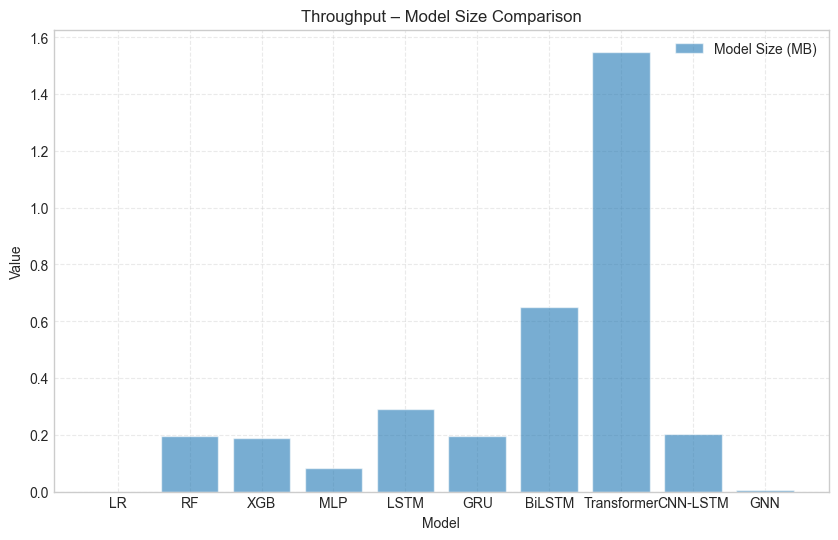

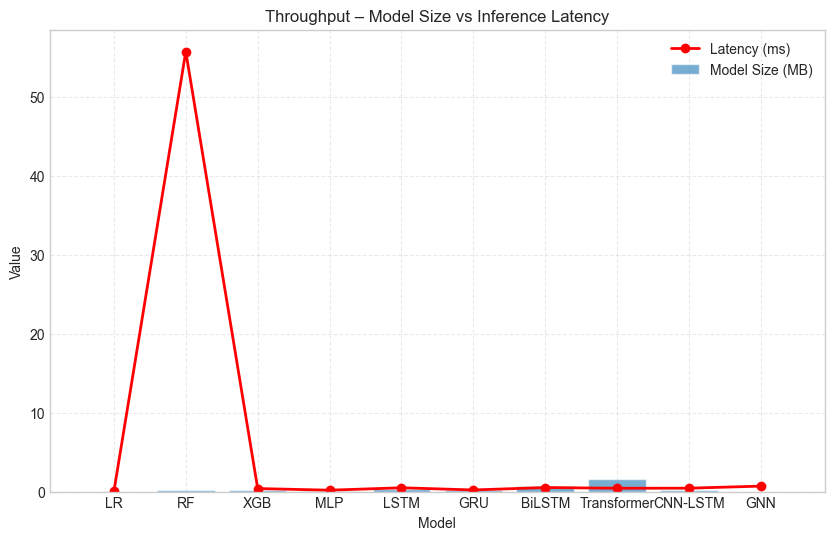

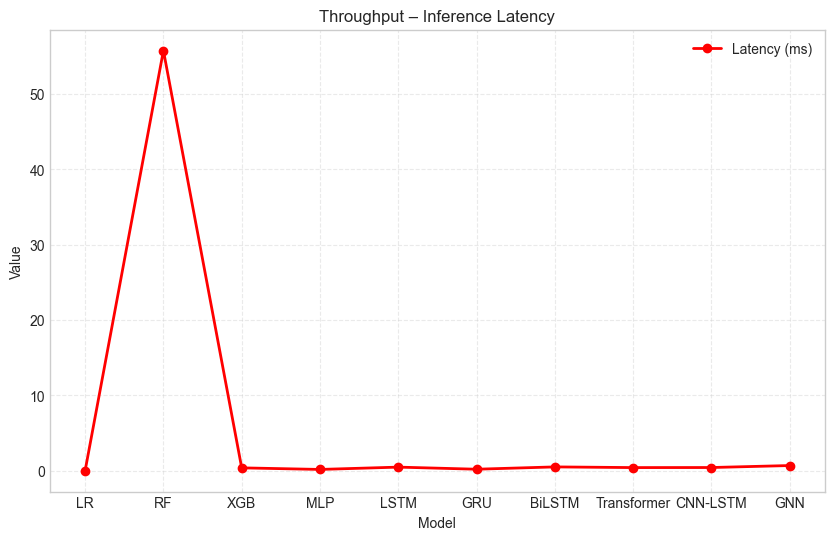

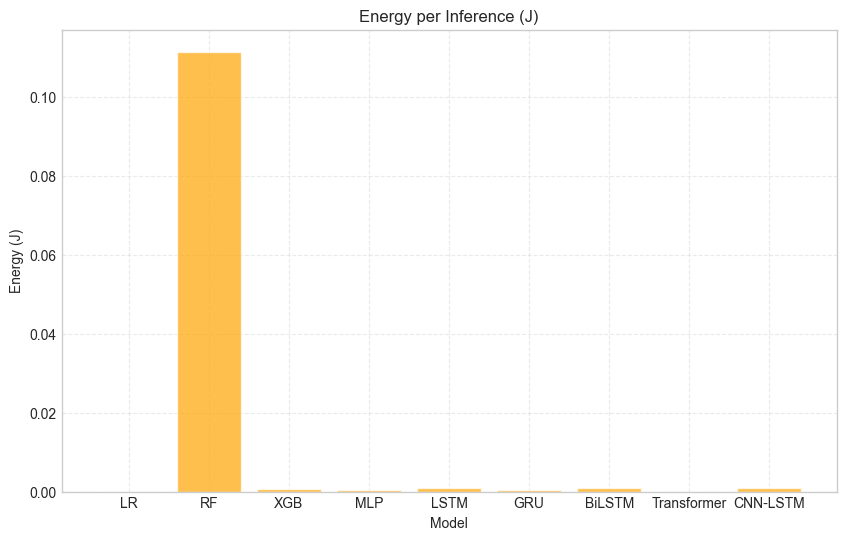

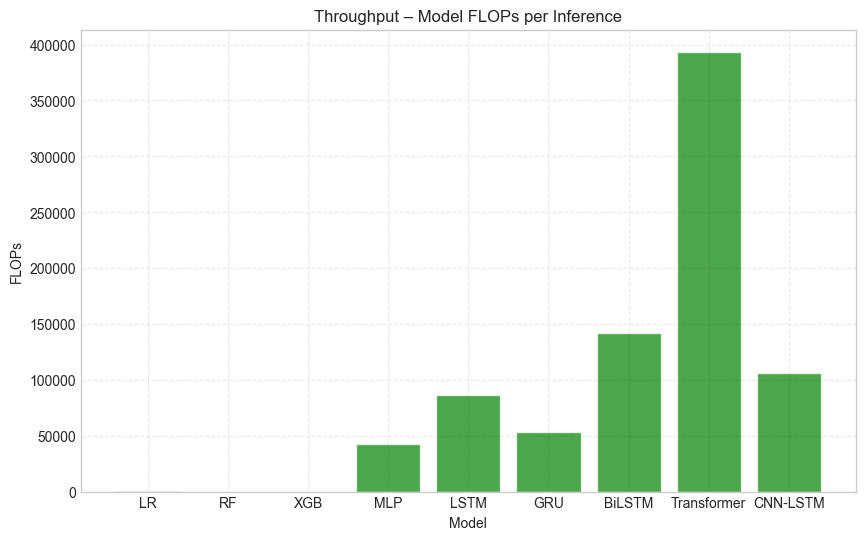

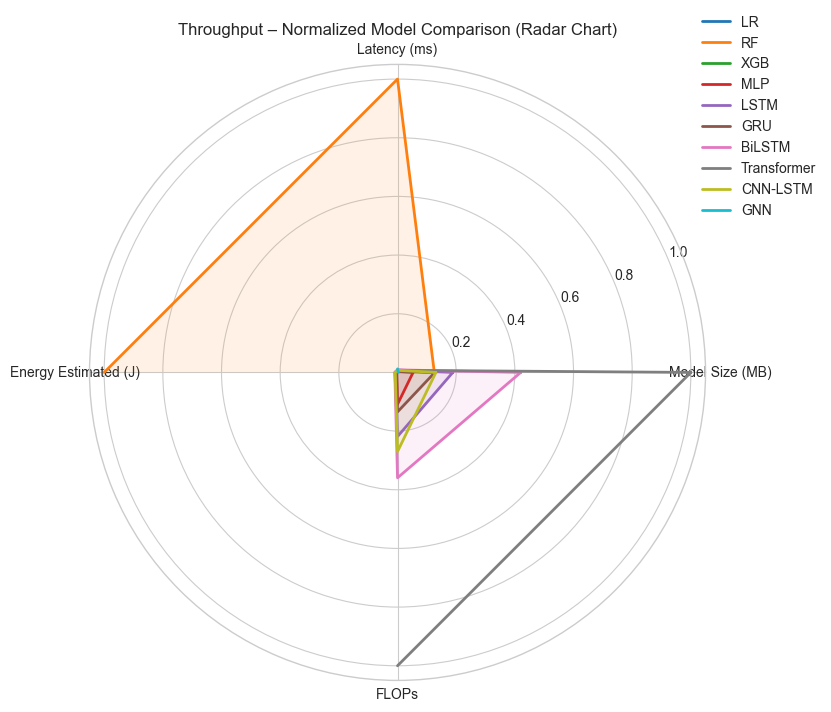

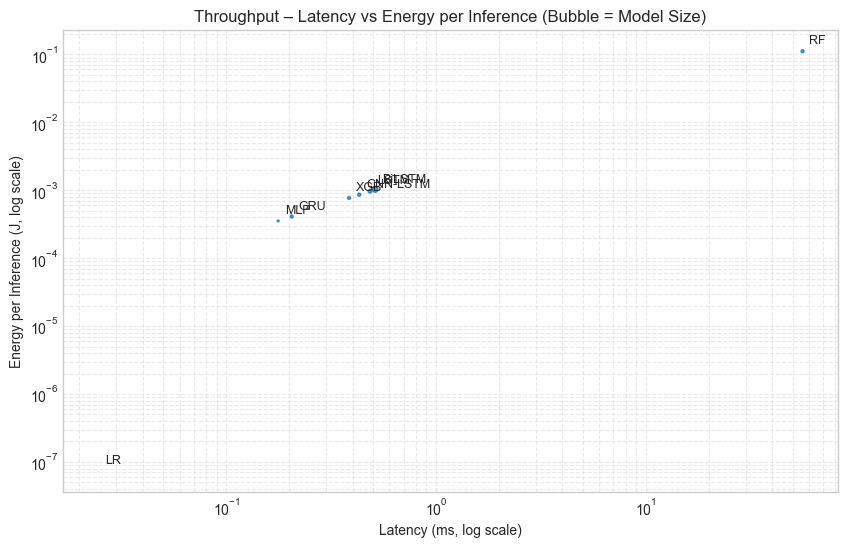

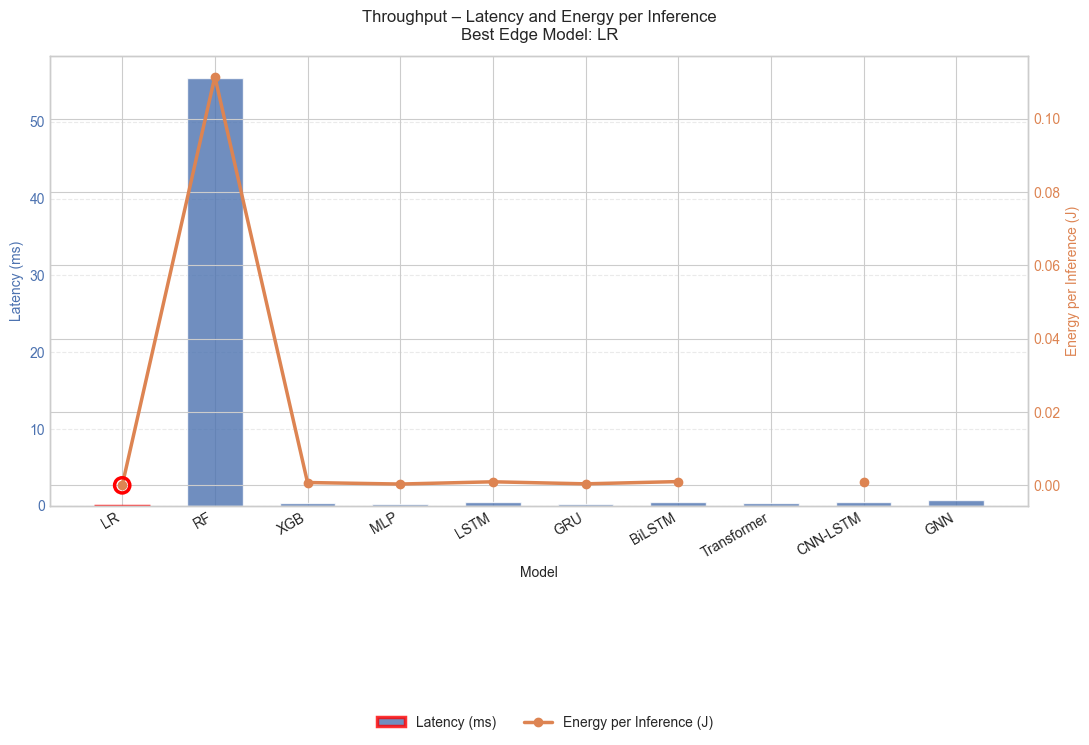


✔ All Throughput edge comparison plots generated successfully.


In [39]:
# Throughput plots
generate_edge_comparison_plots(metric="Throughput",showImage=True)

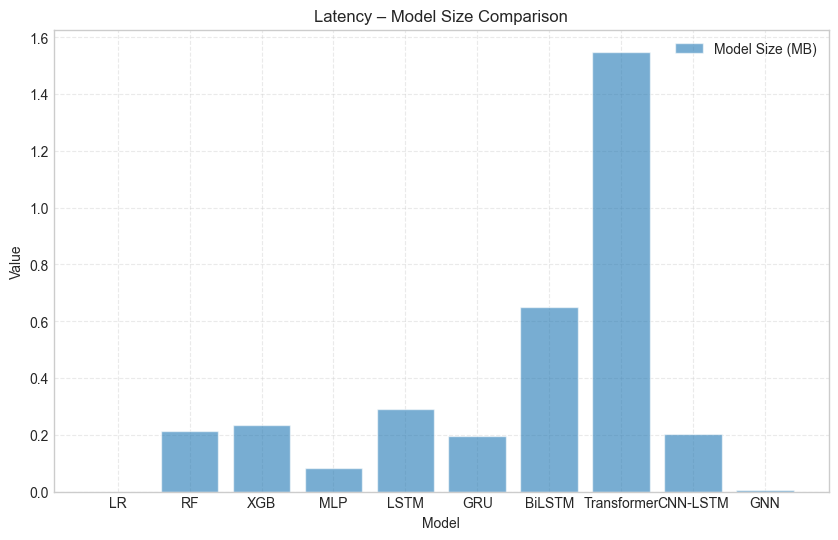

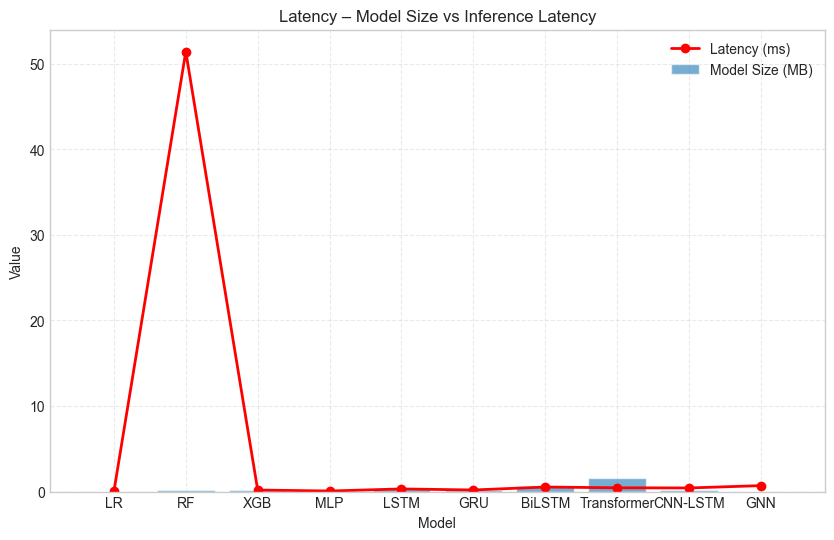

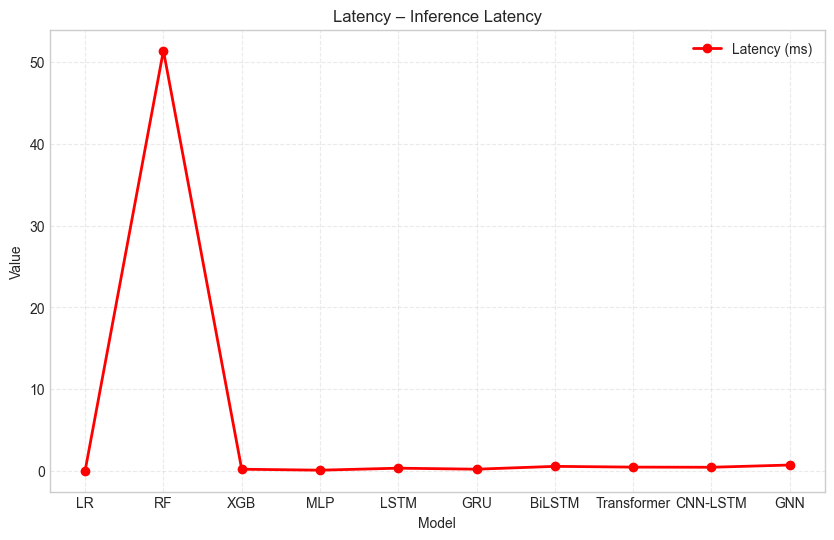

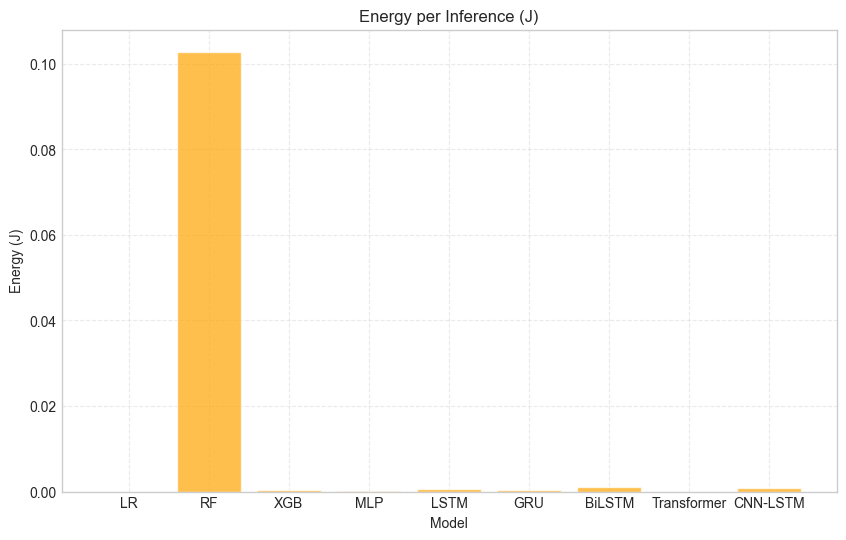

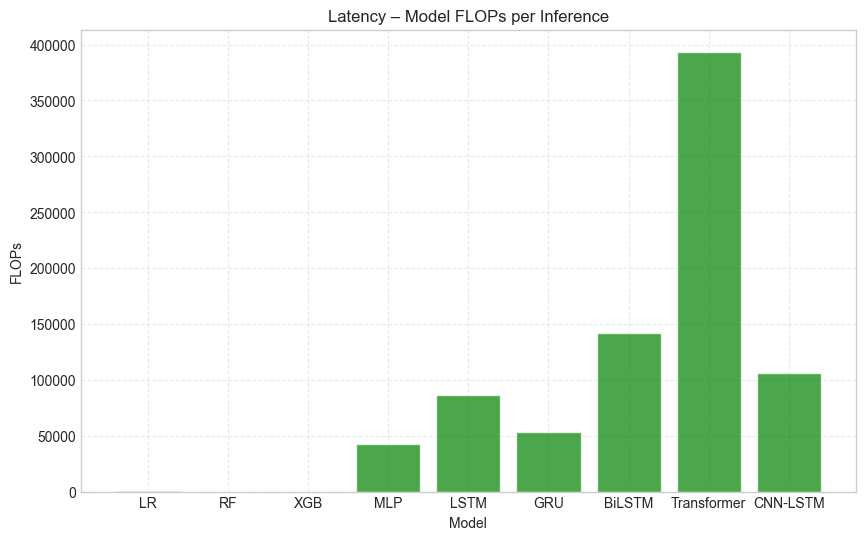

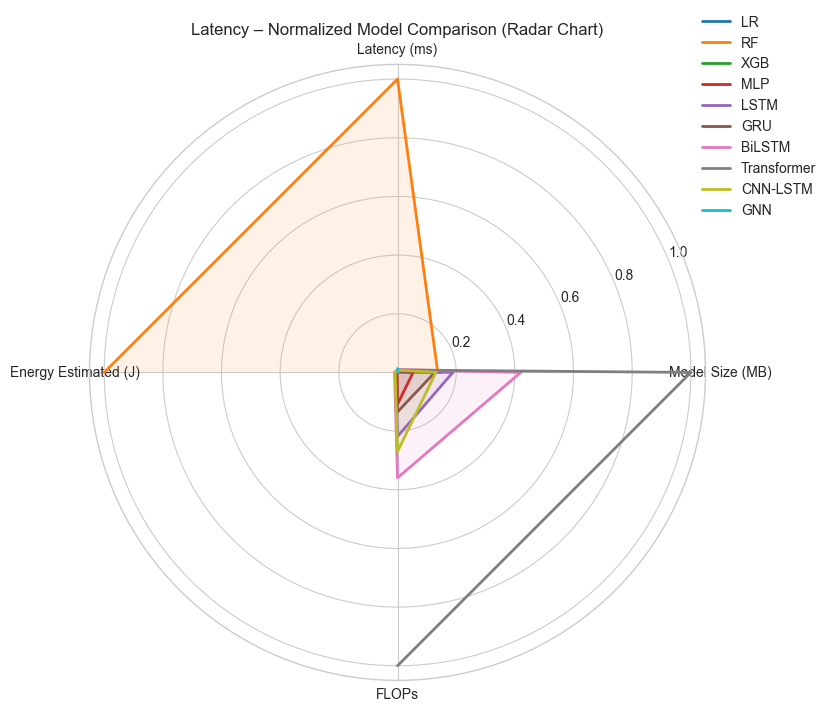

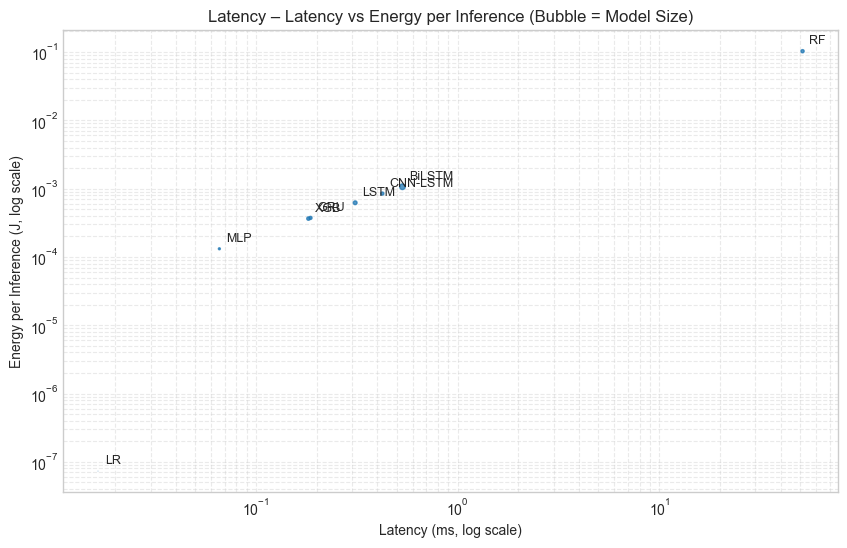

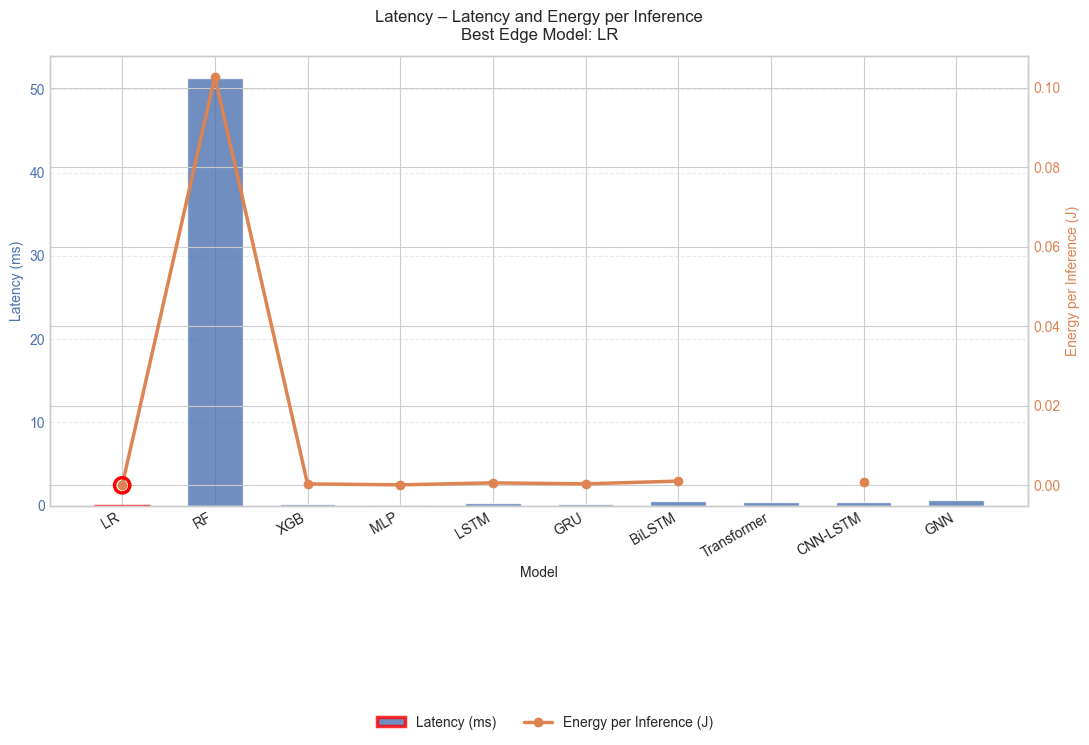


✔ All Latency edge comparison plots generated successfully.


In [40]:
generate_edge_comparison_plots(metric="Latency",showImage=True)


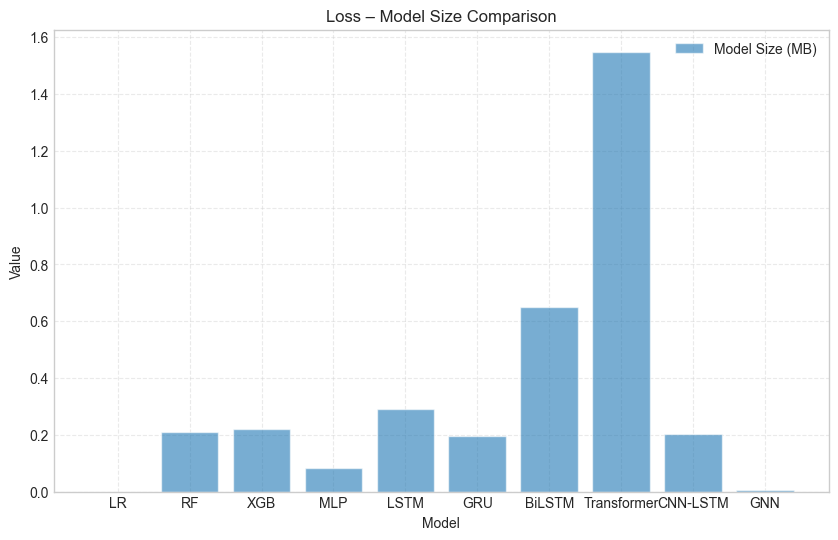

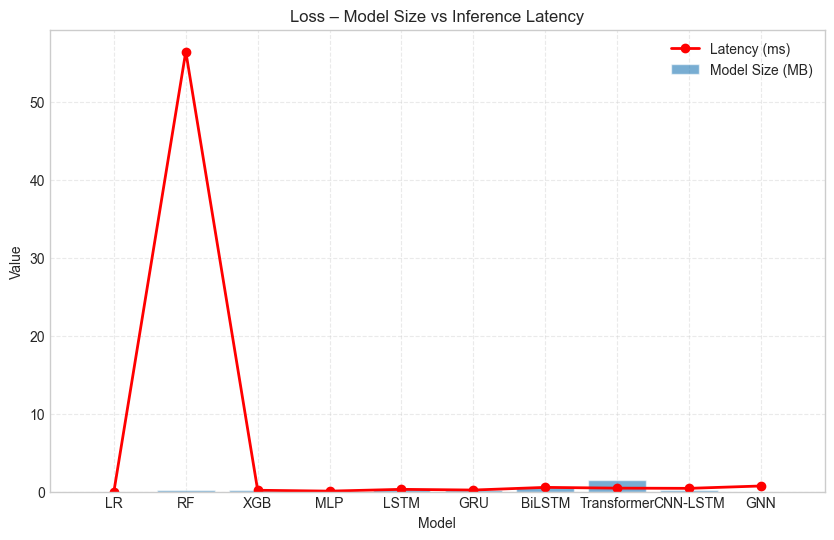

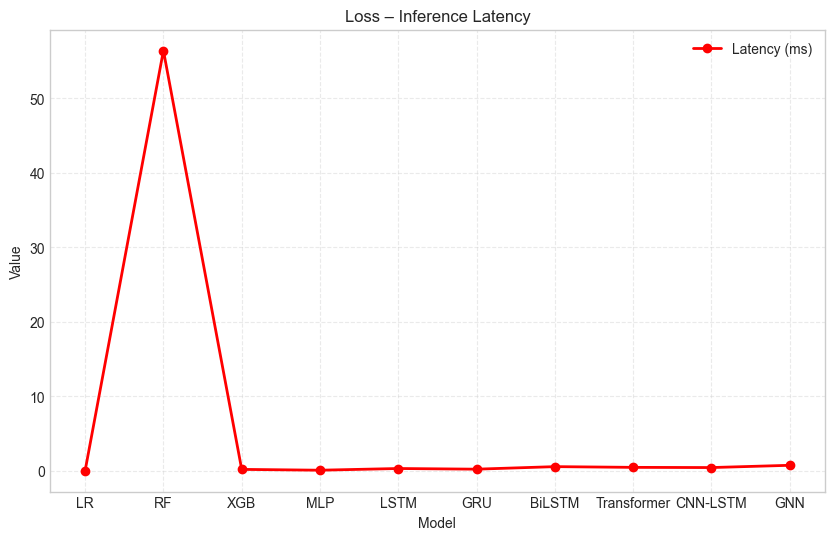

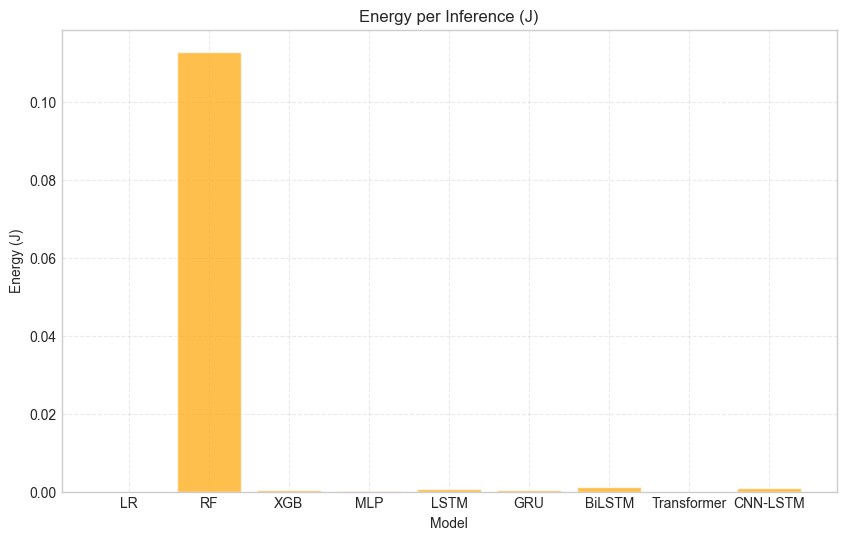

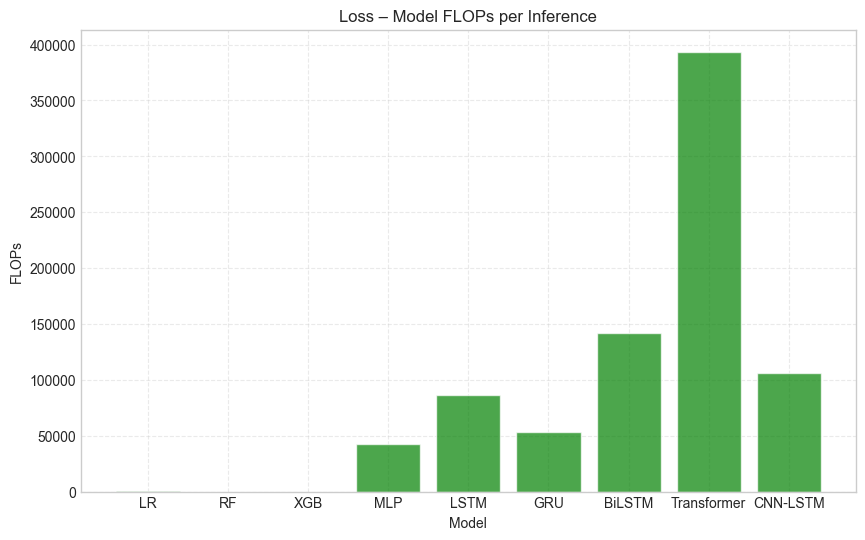

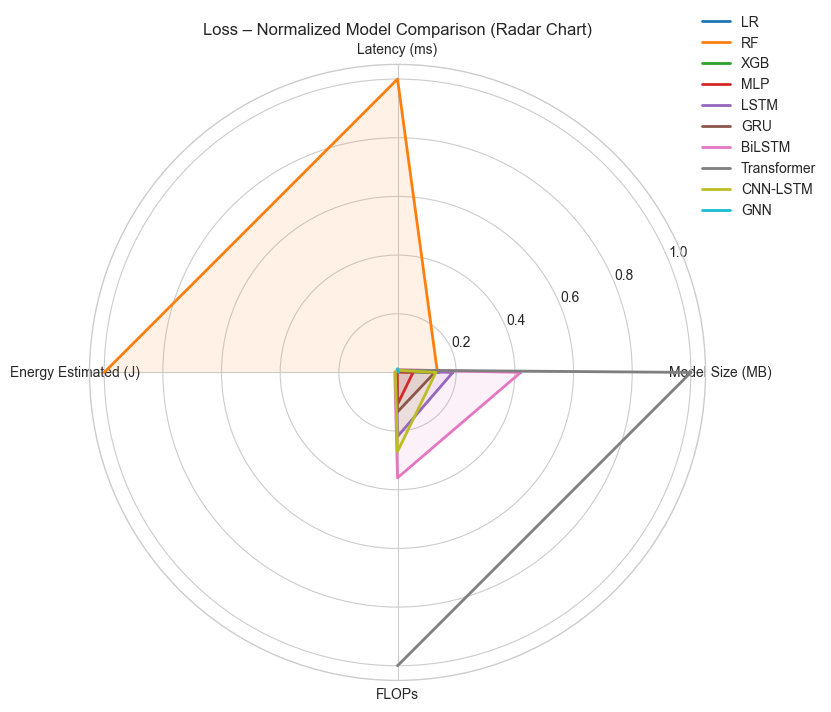

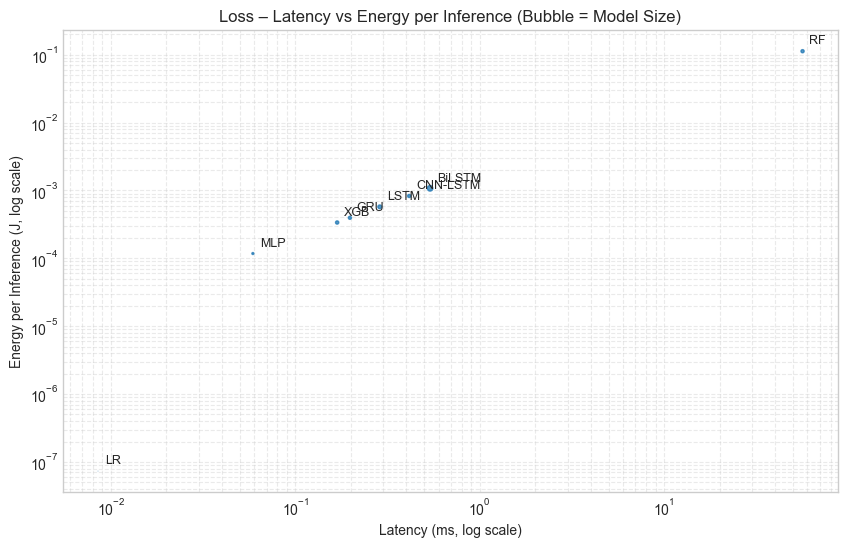

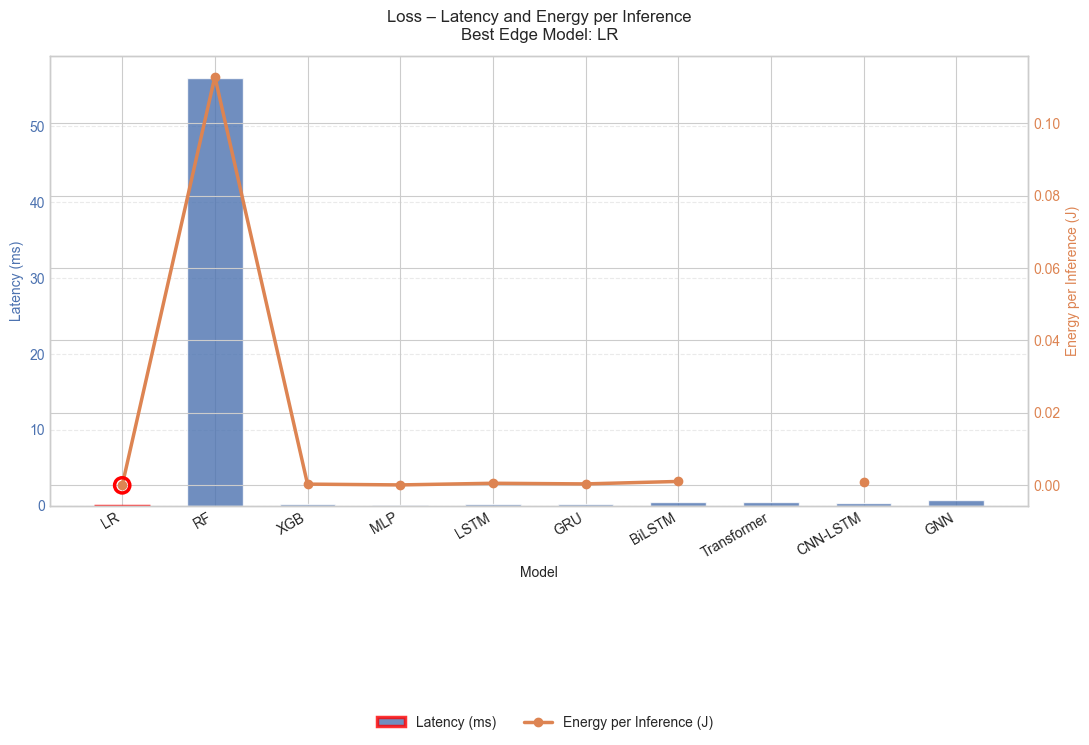


✔ All Loss edge comparison plots generated successfully.


In [41]:
generate_edge_comparison_plots(metric="Loss",showImage=True)

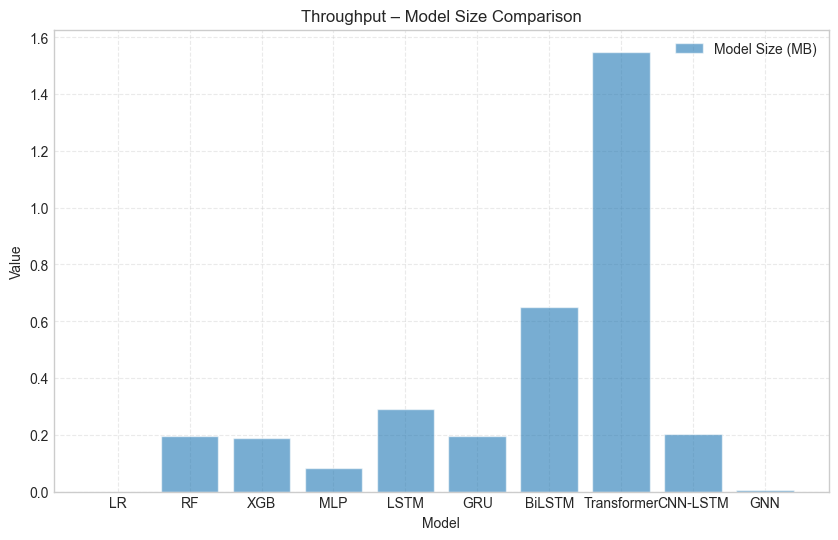

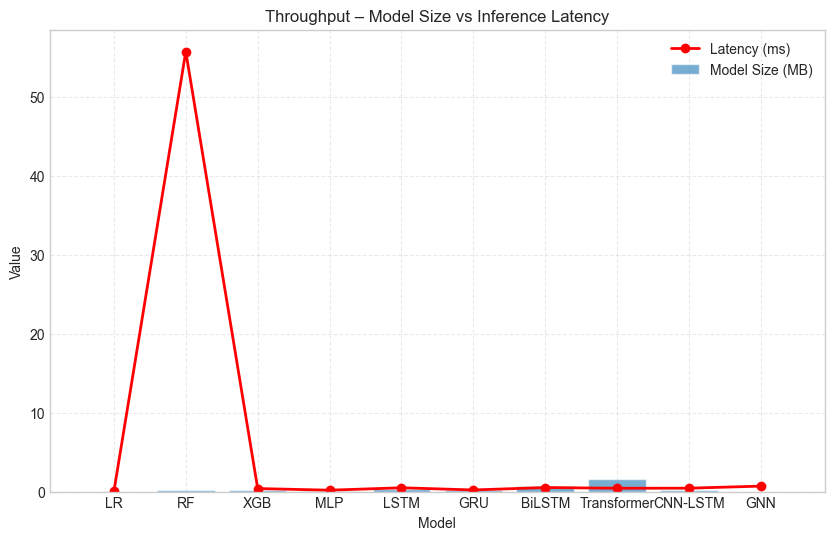

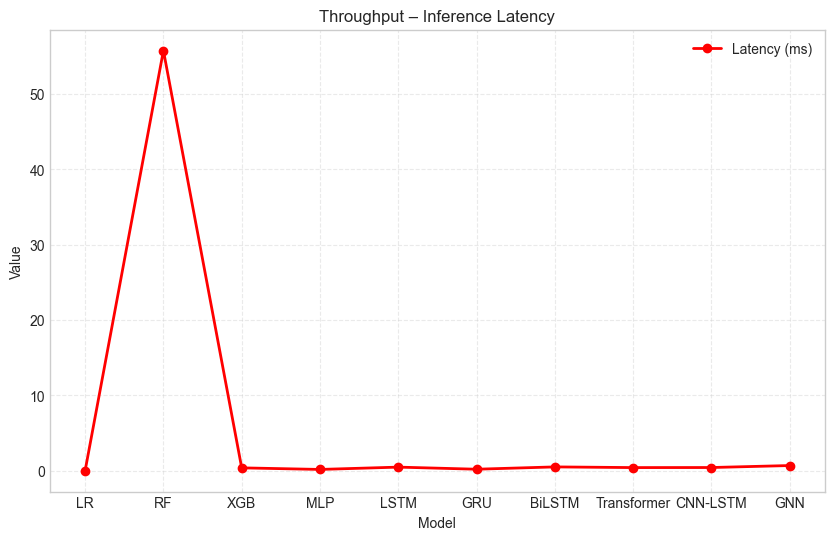

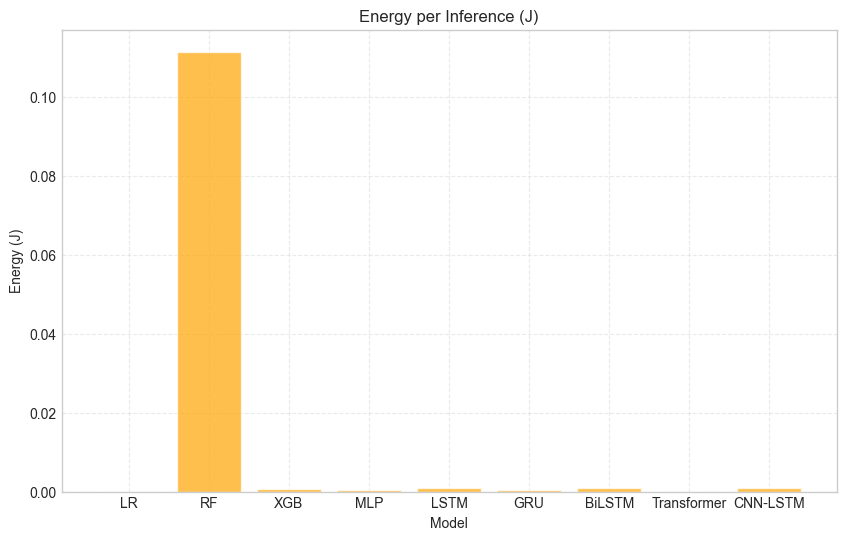

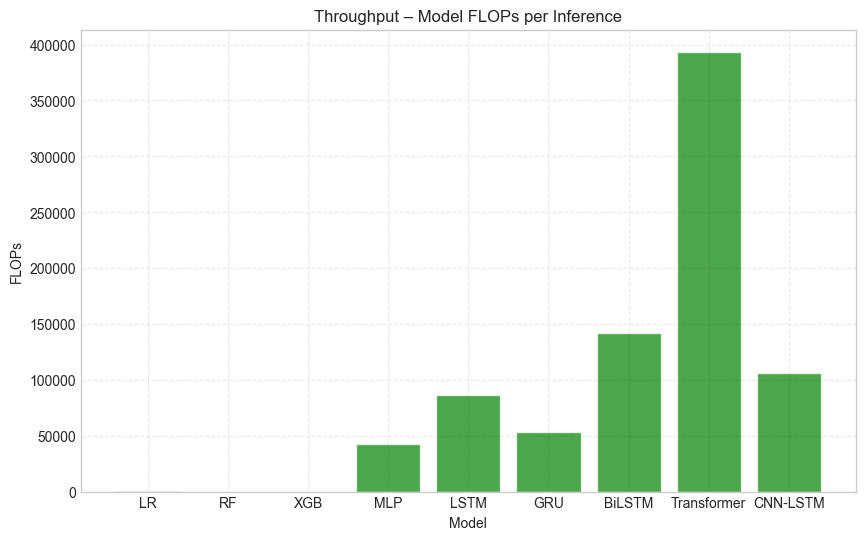

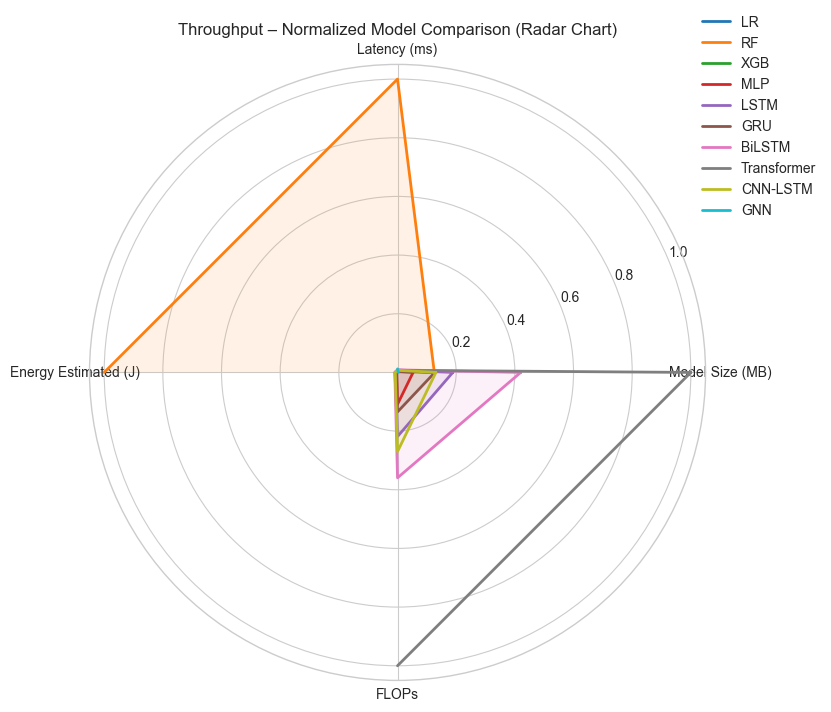

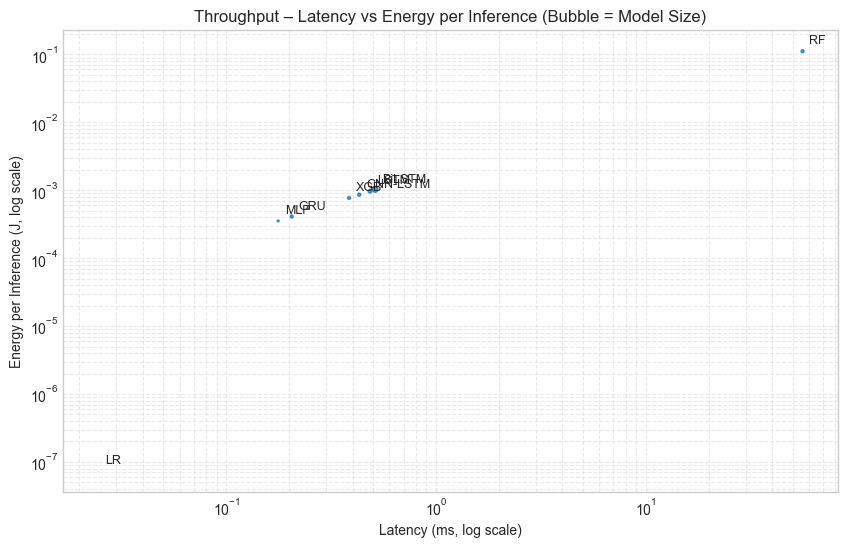

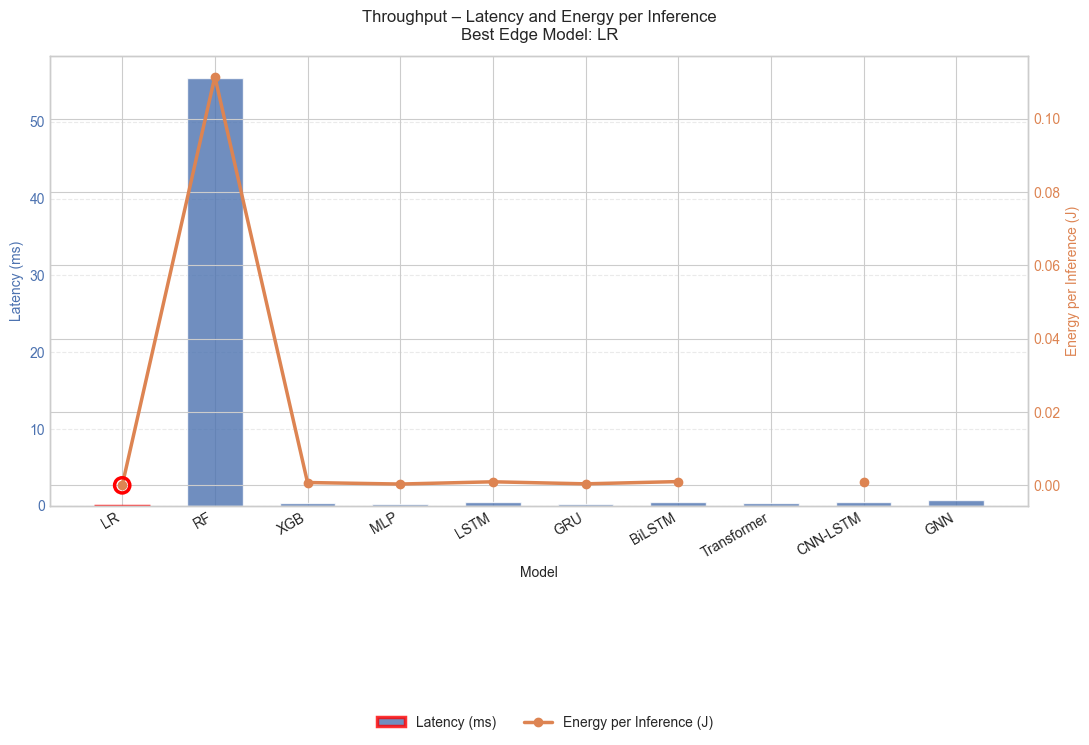


✔ All Throughput edge comparison plots generated successfully.


In [42]:
generate_edge_comparison_plots(showImage=True)

In [43]:
from pathlib import Path


def find_single_csv(base_dir: Path, keyword: str):
    """
    Find exactly one CSV in base_dir containing keyword.
    """
    matches = list(base_dir.glob(f"*{keyword}*.csv"))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"No CSV found in {base_dir} containing '{keyword}'"
        )
    if len(matches) > 1:
        raise ValueError(
            f"Multiple CSVs found in {base_dir} containing '{keyword}':\n"
            + "\n".join(str(p) for p in matches)
        )
    return matches[0]


In [44]:
import pandas as pd
import numpy as np


def compute_accuracy_from_predictions(pred_csv, error_type="rmse"):
    df = pd.read_csv(pred_csv)

    required = {"Model", "y_true", "y_pred"}
    if not required.issubset(df.columns):
        raise ValueError(f"{pred_csv} must contain {required}")

    rows = []
    for model, g in df.groupby("Model"):
        y_true = g["y_true"].values
        y_pred = g["y_pred"].values

        if error_type == "rmse":
            error = np.sqrt(np.mean((y_true - y_pred) ** 2))
        elif error_type == "mae":
            error = np.mean(np.abs(y_true - y_pred))
        else:
            raise ValueError("error_type must be 'rmse' or 'mae'")

        rows.append({
            "Model": model,
            "AccuracyError": error,
        })

    return pd.DataFrame(rows)


In [45]:
import pandas as pd
import numpy as np


def compute_accuracy_from_single_pred_csv(
    csv_path,
    error_type="rmse",
):
    """
    Compute accuracy from one model's prediction CSV.
    """
    df = pd.read_csv(csv_path)

    required = {"y_true", "y_pred"}
    if not required.issubset(df.columns):
        raise ValueError(
            f"{csv_path} must contain columns {required}"
        )

    y_true = df["y_true"].values
    y_pred = df["y_pred"].values

    if error_type == "rmse":
        return np.sqrt(np.mean((y_true - y_pred) ** 2))
    elif error_type == "mae":
        return np.mean(np.abs(y_true - y_pred))
    else:
        raise ValueError("error_type must be 'rmse' or 'mae'")


In [46]:
def normalize_model_key(model_name: str) -> str:
    """
    Convert model display name to filename-safe key.
    """
    return (
        model_name
        .lower()
        .replace("-", "_")
        .replace(" ", "")
    )


In [47]:
METRIC_SUFFIX = {
    "Throughput": "throughput",
    "Latency": "latency",
    "Loss": "loss",
}
from pathlib import Path

from pathlib import Path
import pandas as pd


def generate_accuracy_vs_edge_efficiency_auto(
    metric="Latency",
    split="test",
    error_type="rmse",
):
    """
    Generate accuracy vs edge efficiency CSV using:
    - Edge metrics from run_all_edge_metrics()
    - Per-model prediction CSVs from ../outputs/models/predictions/

    Expected prediction CSV format:
    {model_key}_{metric}_{split}_predictions.csv
    """

    metric_key = METRIC_SUFFIX[metric]

    edge_dir = Path("../outputs/edge_analysis")
    pred_dir = Path("../outputs/models/predictions")

    edge_csv = edge_dir / f"{metric_key}_edge_metrics.csv"
    if not edge_csv.exists():
        raise FileNotFoundError(f"Missing edge CSV: {edge_csv}")

    edge_df = pd.read_csv(edge_csv)
    if "Unnamed: 0" in edge_df.columns:
        edge_df = edge_df.rename(columns={"Unnamed: 0": "Model"})

    rows = []

    for model_name in edge_df["Model"].unique():

        model_key = normalize_model_key(model_name)

        pred_csv = (
            pred_dir /
            f"{model_key}_{metric}_{split}_predictions.csv"
        )

        if not pred_csv.exists():
            raise FileNotFoundError(
                f"Missing prediction CSV for model '{model_name}'.\n"
                f"Expected: {pred_csv}\n"
                f"Available files: {[p.name for p in pred_dir.glob(f'{model_key}_*_{split}_predictions.csv')]}"
            )

        acc_error = compute_accuracy_from_single_pred_csv(
            pred_csv,
            error_type=error_type
        )

        edge_row = edge_df[edge_df["Model"] == model_name].iloc[0]

        rows.append({
            "Model": model_name,
            "AccuracyError": acc_error,
            "Latency_ms": edge_row["Latency (ms)"],
            "ModelSize_MB": edge_row["Model Size (MB)"],
            "FLOPs": edge_row["FLOPs"],
            "Energy_J": edge_row["Energy Estimated (J)"],
        })

    out_df = pd.DataFrame(rows)

    out_path = (
        edge_dir /
        f"{metric_key}_{split}_accuracy_edge_tradeoff.csv"
    )
    out_df.to_csv(out_path, index=False)

    print(f"Saved accuracy–edge trade-off CSV → {out_path}")
    return out_df



In [48]:
df_tradeoff = generate_accuracy_vs_edge_efficiency_auto(
    metric="Throughput",
    split="test",
    error_type="rmse",
)

# print(df_tradeoff)


Saved accuracy–edge trade-off CSV → ../outputs/edge_analysis/throughput_test_accuracy_edge_tradeoff.csv


In [49]:
df_tradeoff = generate_accuracy_vs_edge_efficiency_auto(
    metric="Latency",
    split="test",
    error_type="rmse",
)

Saved accuracy–edge trade-off CSV → ../outputs/edge_analysis/latency_test_accuracy_edge_tradeoff.csv


In [50]:
df_tradeoff = generate_accuracy_vs_edge_efficiency_auto(
    metric="Loss",
    split="test",
    error_type="rmse",
)

Saved accuracy–edge trade-off CSV → ../outputs/edge_analysis/loss_test_accuracy_edge_tradeoff.csv


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def plot_accuracy_vs_edge_efficiency_grouped_bar(
    metric="Latency",
    split="test",
    accuracy_col="AccuracyError",
    latency_col="Latency_ms",
    model_col="Model",
    edge_dir="../outputs/edge_analysis",
    showImage=False,
):
    """
    Grouped bar chart for Accuracy vs Edge Efficiency.

    Reads:
      ../outputs/edge_analysis/{metric}_{split}_accuracy_edge_tradeoff.csv

    Saves:
      ../outputs/edge_analysis/plots/{metric}/compare_{metric}_{split}_edge_grouped_bar.png
    """

    metric_key = metric.lower()

    edge_dir = Path(edge_dir)
    plot_dir = edge_dir / "plots" / metric
    plot_dir.mkdir(parents=True, exist_ok=True)

    csv_path = edge_dir / f"{metric_key}_{split}_accuracy_edge_tradeoff.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Trade-off CSV not found: {csv_path}")

    df = pd.read_csv(csv_path)

    # Sanity check
    for c in [model_col, accuracy_col, latency_col]:
        if c not in df.columns:
            raise ValueError(
                f"Missing column '{c}' in {csv_path.name}. "
                f"Available: {list(df.columns)}"
            )

    models = df[model_col].tolist()
    x = np.arange(len(models))
    width = 0.35

    plt.figure(figsize=(10, 5))

    plt.bar(
        x - width / 2,
        df[accuracy_col],
        width,
        label="Prediction Error (RMSE)"
    )

    plt.bar(
        x + width / 2,
        df[latency_col],
        width,
        label="Inference Latency (ms)"
    )

    plt.xlabel("Model")
    plt.ylabel("Value")
    plt.title(
        f"Accuracy vs Edge Efficiency ({metric}, {split} set)"
    )

    plt.xticks(x, models, rotation=30, ha="right")
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()

    out_path = (
        plot_dir /
        f"compare_{metric_key}_{split}_edge_grouped_bar.png"
    )
    plt.savefig(out_path, dpi=300)
    if showImage:
        plt.show()
    plt.close()

    print(f"Saved grouped bar plot → {out_path}")


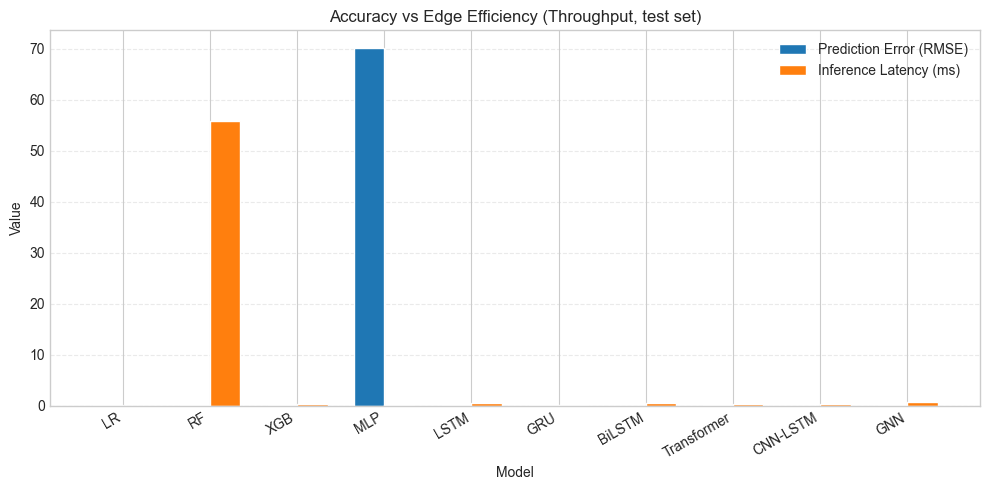

Saved grouped bar plot → ../outputs/edge_analysis/plots/Throughput/compare_throughput_test_edge_grouped_bar.png


In [52]:
plot_accuracy_vs_edge_efficiency_grouped_bar(
    metric="Throughput",
    split="test",
    showImage=True
)

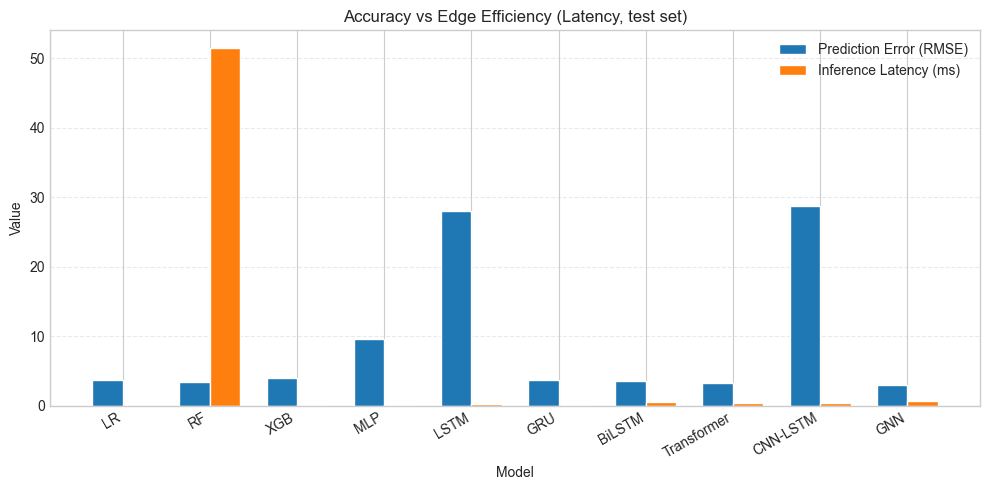

Saved grouped bar plot → ../outputs/edge_analysis/plots/Latency/compare_latency_test_edge_grouped_bar.png


In [53]:
plot_accuracy_vs_edge_efficiency_grouped_bar(
    metric="Latency",
    split="test",
    showImage=True
)


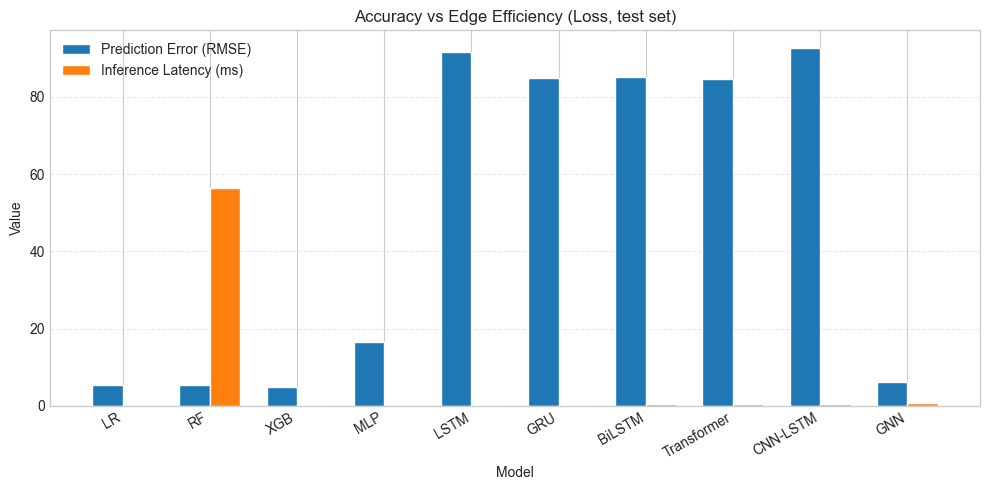

Saved grouped bar plot → ../outputs/edge_analysis/plots/Loss/compare_loss_test_edge_grouped_bar.png


In [54]:
plot_accuracy_vs_edge_efficiency_grouped_bar(
    metric="Loss",
    split="test",
    showImage=True
)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def plot_accuracy_bar_latency_line(
    metric="Latency",
    split="test",
    accuracy_col="AccuracyError",
    latency_col="Latency_ms",
    model_col="Model",
    edge_dir="../outputs/edge_analysis",
    showImage=False,
):
    """
    Plot prediction error as BAR and inference latency as LINE.

    Reads:
      ../outputs/edge_analysis/{metric}_{split}_accuracy_edge_tradeoff.csv

    Saves:
      ../outputs/edge_analysis/plots/{metric}/compare_{metric}_{split}_edge_bar_line.png
    """

    metric_key = metric.lower()

    edge_dir = Path(edge_dir)
    plot_dir = edge_dir / "plots" / metric
    plot_dir.mkdir(parents=True, exist_ok=True)

    csv_path = edge_dir / f"{metric_key}_{split}_accuracy_edge_tradeoff.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Trade-off CSV not found: {csv_path}")

    df = pd.read_csv(csv_path)

    # Sanity check
    for c in [model_col, accuracy_col, latency_col]:
        if c not in df.columns:
            raise ValueError(
                f"Missing column '{c}' in {csv_path.name}. "
                f"Available: {list(df.columns)}"
            )

    models = df[model_col].tolist()
    x = np.arange(len(models))

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # -----------------------------
    # Bar: Prediction Error
    # -----------------------------
    bars = ax1.bar(
        x,
        df[accuracy_col],
        width=0.6,
        alpha=0.8,
        label="Prediction Error (RMSE)"
    )

    ax1.set_xlabel("Model")
    ax1.set_ylabel("Prediction Error (RMSE)")
    ax1.set_xticks(x)
    ax1.set_xticklabels(models, rotation=30, ha="right")
    ax1.grid(axis="y", linestyle="--", alpha=0.4)

    # -----------------------------
    # Line: Inference Latency
    # -----------------------------
    ax2 = ax1.twinx()
    ax2.plot(
        x,
        df[latency_col],
        color="red",
        marker="o",
        linewidth=2,
        label="Inference Latency (ms)"
    )
    ax2.set_ylabel("Inference Latency (ms)")

    # -----------------------------
    # Title & Legend
    # -----------------------------
    plt.title(
        f"Prediction Accuracy vs Edge Efficiency ({metric}, {split} set)"
    )

    # Combined legend
    lines_labels = (
        ax1.get_legend_handles_labels()[0]
        + ax2.get_legend_handles_labels()[0],
        ax1.get_legend_handles_labels()[1]
        + ax2.get_legend_handles_labels()[1]
    )
    ax1.legend(*lines_labels, loc="upper left")

    plt.tight_layout()

    out_path = (
        plot_dir /
        f"compare_{metric_key}_{split}_edge_bar_line.png"
    )
    plt.savefig(out_path, dpi=300)
    if showImage:
        plt.show()
    plt.close()

    print(f"Saved bar–line plot → {out_path}")


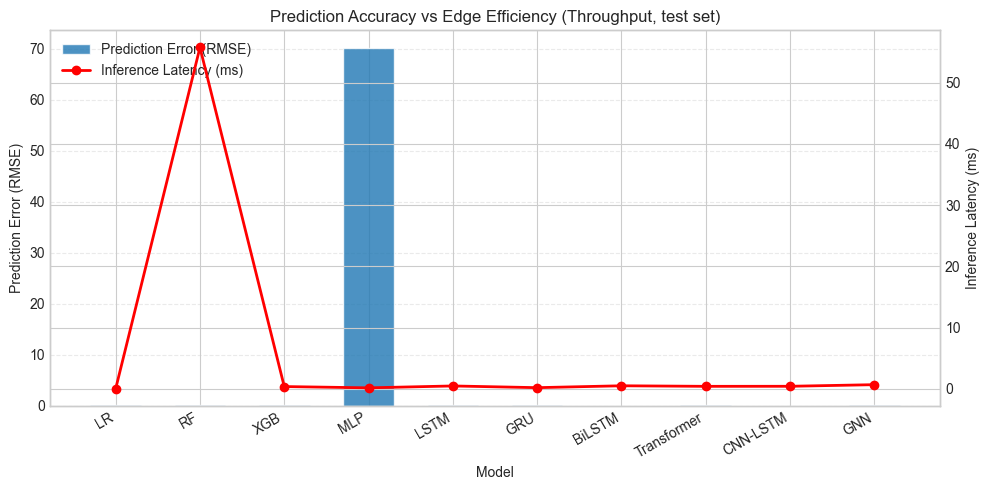

Saved bar–line plot → ../outputs/edge_analysis/plots/Throughput/compare_throughput_test_edge_bar_line.png


In [56]:
plot_accuracy_bar_latency_line(
    metric="Throughput",
    split="test",
    showImage=True
)


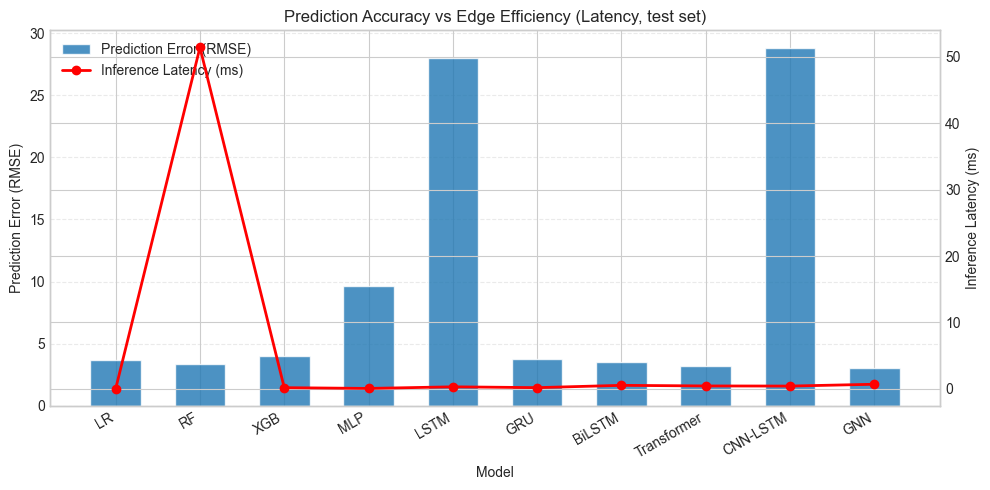

Saved bar–line plot → ../outputs/edge_analysis/plots/Latency/compare_latency_test_edge_bar_line.png


In [57]:
plot_accuracy_bar_latency_line(
    metric="Latency",
    split="test",
    showImage=True
)

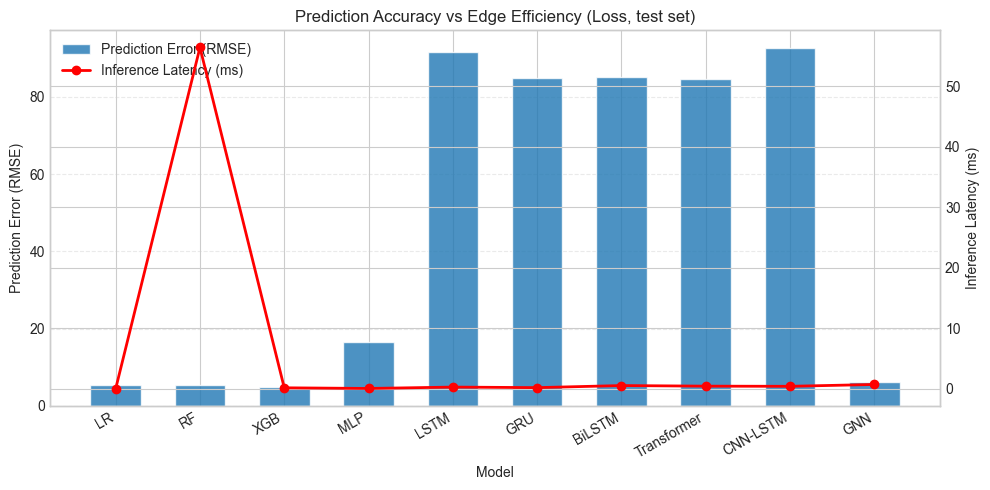

Saved bar–line plot → ../outputs/edge_analysis/plots/Loss/compare_loss_test_edge_bar_line.png


In [58]:
plot_accuracy_bar_latency_line(
    metric="Loss",
    split="test",
    showImage=True
)

In [34]:
import pandas as pd

df_t = pd.read_csv("../outputs/edge_analysis/throughput_edge_metrics.csv")
df_l = pd.read_csv("../outputs/edge_analysis/latency_edge_metrics.csv")
df_loss = pd.read_csv("../outputs/edge_analysis/loss_edge_metrics.csv")

print("throughput:", df_t.columns.tolist())
print("latency   :", df_l.columns.tolist())
print("loss      :", df_loss.columns.tolist())

display(df_t.head())

throughput: ['Unnamed: 0', 'Parameters', 'Model Size (Bytes)', 'Model Size (MB)', 'FLOPs', 'Latency (s)', 'Latency (ms)', 'Energy Estimated (J)', 'Peak Activation Memory (Bytes)', 'Model Path', 'Trees', 'Total Nodes', 'Average Nodes per Tree', 'Average Tree Depth', 'Max Tree Depth', 'Input Dim', 'Estimated Energy (J)', 'Num Nodes', 'Node Feature Dim', 'Hidden Dim']
latency   : ['Unnamed: 0', 'Parameters', 'Model Size (Bytes)', 'Model Size (MB)', 'FLOPs', 'Latency (s)', 'Latency (ms)', 'Energy Estimated (J)', 'Peak Activation Memory (Bytes)', 'Model Path', 'Trees', 'Total Nodes', 'Average Nodes per Tree', 'Average Tree Depth', 'Max Tree Depth', 'Input Dim', 'Estimated Energy (J)', 'Num Nodes', 'Node Feature Dim', 'Hidden Dim']
loss      : ['Unnamed: 0', 'Parameters', 'Model Size (Bytes)', 'Model Size (MB)', 'FLOPs', 'Latency (s)', 'Latency (ms)', 'Energy Estimated (J)', 'Peak Activation Memory (Bytes)', 'Model Path', 'Trees', 'Total Nodes', 'Average Nodes per Tree', 'Average Tree Depth'

,Unnamed: 0,Parameters,Model Size (Bytes),Model Size (MB),FLOPs,Latency (s),Latency (ms),Energy Estimated (J),Peak Activation Memory (Bytes),Model Path,Trees,Total Nodes,Average Nodes per Tree,Average Tree Depth,Max Tree Depth,Input Dim,Estimated Energy (J),Num Nodes,Node Feature Dim,Hidden Dim
0,LR,74.0,296.0,0.000282,146.0,0.000025,0.024513,7.300000e-08,4,../outputs/models/lr_model_throughput.pkl,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RF,NaN,204161.0,0.194703,NaN,0.055742,55.742058,1.114841e-01,584,../outputs/models/rf_model_throughput.pkl,300.0,1500.0,5.00,2.000,2.0,NaN,NaN,NaN,NaN,NaN
2,XGB,NaN,196385.0,0.187287,NaN,0.000385,0.385381,7.707628e-04,584,../outputs/models/xgb_model_throughput.json,400.0,912.0,2.28,0.625,4.0,NaN,NaN,NaN,NaN,NaN
3,MLP,21633.0,86532.0,0.082523,42880.0,0.000177,0.176796,3.535921e-04,4,../outputs/models/mlp_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,103.0,NaN,NaN,NaN,NaN
4,LSTM,76609.0,306436.0,0.292240,86144.0,0.000484,0.484178,9.683553e-04,4,../outputs/models/lstm_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,103.0,NaN,NaN,NaN,NaN


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def plot_multi_target_edge_bar_line(
    throughput_csv="../outputs/edge_analysis/throughput_edge_metrics.csv",
    latency_csv="../outputs/edge_analysis/latency_edge_metrics.csv",
    loss_csv="../outputs/edge_analysis/loss_edge_metrics.csv",
    edge_dir="../outputs/edge_analysis",
):
    dfs = {
        "throughput": pd.read_csv(throughput_csv),
        "latency": pd.read_csv(latency_csv),
        "loss": pd.read_csv(loss_csv),
    }

    records = []

    for target, df in dfs.items():
        tmp = df.copy()

        # ---------- detect model column ----------
        model_col = None
        for c in ["Model", "model", "Model Name", "model_name"]:
            if c in tmp.columns:
                model_col = c
                break

        # if model names are stored in index
        if model_col is None:
            if tmp.index.name in ["Model", "model", "Model Name", "model_name"]:
                tmp = tmp.reset_index()
                model_col = tmp.columns[0]
            elif "Unnamed: 0" in tmp.columns:
                model_col = "Unnamed: 0"

        # ---------- detect latency column ----------
        latency_col = None
        for c in [
            "Latency (ms)",
            "Inference Latency (ms)",
            "Latency (ms/sample)",
            "Latency (ms per sample)",
            "Latency (ms per Sample)",
            "Latency (ms/sample )"
        ]:
            if c in tmp.columns:
                latency_col = c
                break

        if model_col is None:
            raise ValueError(
                f"No model column found in {target} CSV. Columns: {list(tmp.columns)}"
            )

        if latency_col is None:
            raise ValueError(
                f"No latency column found in {target} CSV. Columns: {list(tmp.columns)}"
            )

        tmp = tmp[[model_col, latency_col]].copy()
        tmp.rename(
            columns={
                model_col: "Model",
                latency_col: "Edge Latency (ms)"
            },
            inplace=True
        )
        tmp["Target"] = target
        records.append(tmp)

    combined = pd.concat(records, ignore_index=True)

    pivot = combined.pivot_table(
        index="Model",
        columns="Target",
        values="Edge Latency (ms)"
    )

    desired_order = [
        "LR", "RF", "XGBoost", "MLP", "LSTM",
        "GRU", "BiLSTM", "Transformer", "CNN-LSTM", "GNN"
    ]
    existing_order = [m for m in desired_order if m in pivot.index]
    remaining = [m for m in pivot.index if m not in existing_order]
    pivot = pivot.reindex(existing_order + remaining)

    fig, ax1 = plt.subplots(figsize=(13, 6))
    pivot.plot(
        kind="bar",
        ax=ax1,
        edgecolor="black"
    )

    ax1.set_ylabel("Edge Latency (ms)")
    ax1.set_xlabel("Model")
    ax1.set_title("Edge Latency Across Targets")
    ax1.grid(axis="y", linestyle="--", alpha=0.5)

    avg_latency = pivot.mean(axis=1)

    # ax2 = ax1.twinx()
    # ax2.plot(
    #     np.arange(len(avg_latency)),
    #     avg_latency.values,
    #     color="red",
    #     marker="o",
    #     linewidth=2
    # )
    # ax2.set_ylabel("Average Edge Latency (ms)")

    ax1.set_xticklabels(pivot.index, rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(
        Path(edge_dir) / "compare_all_targets_edge_latency.png",
        dpi=300,
        bbox_inches="tight"
        )

    plt.show()
    
    return combined, pivot

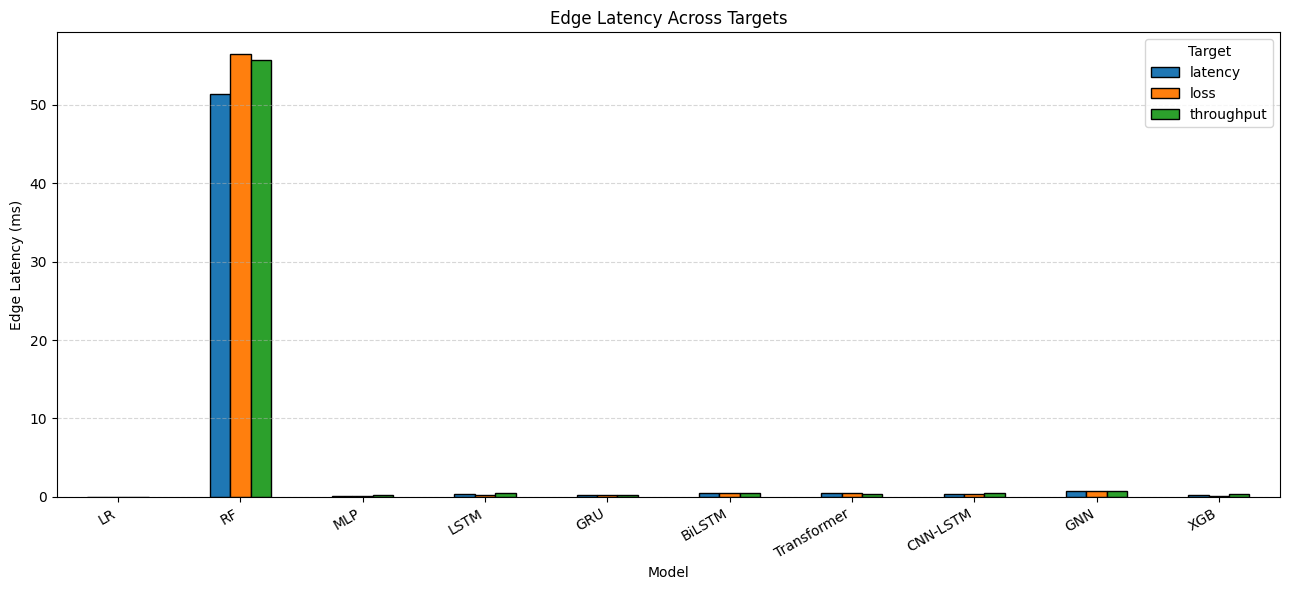

(          Model  Edge Latency (ms)      Target
 0            LR           0.024513  throughput
 1            RF          55.742058  throughput
 2           XGB           0.385381  throughput
 3           MLP           0.176796  throughput
 4          LSTM           0.484178  throughput
 5           GRU           0.205193  throughput
 6        BiLSTM           0.512561  throughput
 7   Transformer           0.422172  throughput
 8      CNN-LSTM           0.430555  throughput
 9           GNN           0.693521  throughput
 10           LR           0.016471     latency
 11           RF          51.414001     latency
 12          XGB           0.182134     latency
 13          MLP           0.065858     latency
 14         LSTM           0.310661     latency
 15          GRU           0.186465     latency
 16       BiLSTM           0.532998     latency
 17  Transformer           0.441553     latency
 18     CNN-LSTM           0.423471     latency
 19          GNN           0.696391     

In [27]:
plot_multi_target_edge_bar_line()
# print(df_t.columns.tolist())
# display(df_t.head())

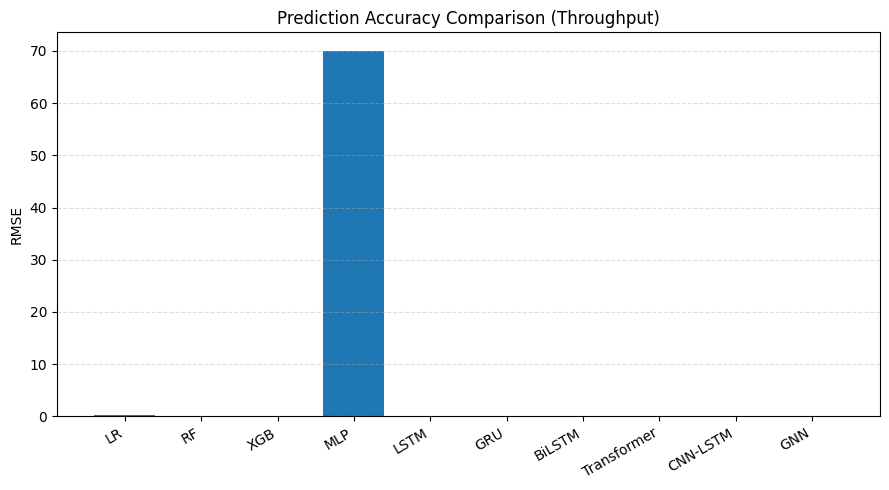

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../outputs/edge_analysis/throughput_test_accuracy_edge_tradeoff.csv"
)

plt.figure(figsize=(9, 5))
plt.bar(df["Model"], df["AccuracyError"])

plt.ylabel("RMSE")
plt.title("Prediction Accuracy Comparison (Throughput)")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("rmse_comparison.png", dpi=300)
plt.show()


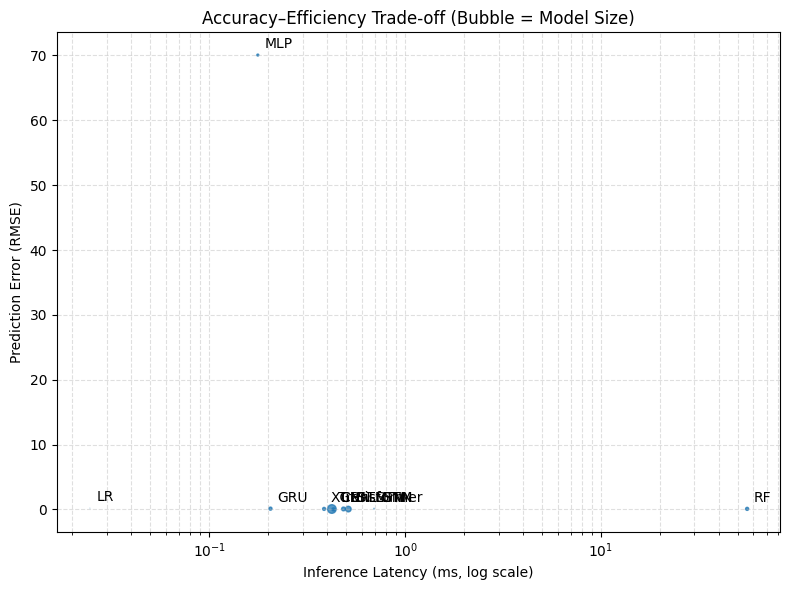

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = df["Latency_ms"]
y = df["AccuracyError"]
sizes = df["ModelSize_MB"] * 25

plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=sizes, alpha=0.75)

for i, model in enumerate(df["Model"]):
    plt.annotate(model, (x[i], y[i]), xytext=(5,5),
                 textcoords="offset points")

plt.xscale("log")
plt.xlabel("Inference Latency (ms, log scale)")
plt.ylabel("Prediction Error (RMSE)")
plt.title("Accuracy–Efficiency Trade-off (Bubble = Model Size)")
plt.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("accuracy_efficiency_tradeoff.png", dpi=300)
plt.show()



In [ ]:
# decision = {
#     "Model": df["Model"],
#     "Decision": [
#         "Baseline" if m in ["LR", "RF"]
#         else "Edge-suitable" if m in ["GRU", "CNN-LSTM"]
#         else "Upper-bound reference"
#         for m in df["Model"]
#     ]
# }

# pd.DataFrame(decision)


,Model,Decision
0,LR,Baseline
1,RF,Baseline
2,XGB,Upper-bound reference
3,MLP,Upper-bound reference
4,LSTM,Upper-bound reference
5,GRU,Edge-suitable
6,BiLSTM,Upper-bound reference
7,Transformer,Upper-bound reference
8,CNN-LSTM,Edge-suitable
9,GNN,Upper-bound reference


In [2]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

comp_eval_dir = os.path.abspath("computational_evaluations")
if comp_eval_dir not in sys.path:
    sys.path.append(comp_eval_dir)

from computational_evaluations.run_all_computional import run_evaluations, OUTPUT_DIR

In [3]:
metric_keys = ["throughput", "latency", "loss"]

computational_results = {}
computational_dfs = {}

for metric_key in metric_keys:
    results = run_evaluations(metric_key)
    df = pd.DataFrame(results).drop(columns=["Model Path"], errors="ignore")
    
    out_csv = os.path.join(OUTPUT_DIR, f"{metric_key}_computational_metrics.csv")
    df.to_csv(out_csv, index=False)
    
    computational_results[metric_key] = results
    computational_dfs[metric_key] = df
    
    print(f"Saved: {out_csv}")
    display(df)

[INFO] Running computational evaluation for: throughput


throughput models:  90%|█████████ | 9/10 [00:00<00:00, 14.03it/s]c:\Users\satnaingtun.DESKTOP-4FQHRHU\Documents\SatNaingTun\AIT_Projects\NS3-Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
throughput models: 100%|██████████| 10/10 [00:02<00:00,  4.13it/s]

Saved: c:\Users\satnaingtun.DESKTOP-4FQHRHU\Documents\SatNaingTun\AIT_Projects\NS3-Project\outputs\computational_analysis\throughput_computational_metrics.csv


,Model,Model Size (MB),Computational Latency (ms/sample),Energy (J/sample),Num Parameters,Trees,Total Nodes,Average Nodes per Tree,Average Tree Depth,Max Tree Depth,Model Size (Bytes),Computational Latency (s/sample),Energy Estimated (J/sample),Peak Activation Memory (Bytes),Batch Size (Repeats),Parameters
0,LR,0.001222,0.000098,1.968000e-07,74.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RF,0.194703,0.008846,NaN,NaN,300.0,1500.0,5.0,2.0,2.0,204161.0,0.000009,0.000018,292.0,1000.0,NaN
2,XGBoost,0.187287,0.000963,1.925800e-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MLP,0.082523,0.000505,1.010400e-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21633.0
4,LSTM,0.292240,0.007668,1.533600e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76609.0
5,GRU,0.197269,0.007802,1.560400e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51713.0
6,BiLSTM,0.650883,0.016804,3.360800e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170625.0
7,Transformer,1.549320,0.028036,5.607200e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,406145.0
8,CNN-LSTM,0.202885,0.005526,1.105240e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53185.0
9,GNN,0.004642,0.261416,1.307080e-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1217.0


[INFO] Running computational evaluation for: latency


...

,Model,Model Size (MB),Computational Latency (ms/sample),Energy (J/sample),Num Parameters,Trees,Total Nodes,Average Nodes per Tree,Average Tree Depth,Max Tree Depth,Model Size (Bytes),Computational Latency (s/sample),Energy Estimated (J/sample),Peak Activation Memory (Bytes),Batch Size (Repeats),Parameters
0,LR,0.001222,0.000083,1.650001e-07,74.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RF,0.212968,0.007573,NaN,NaN,300.0,1766.0,5.886667,2.373333,3.0,223313.0,0.000008,0.000015,292.0,1000.0,NaN
2,XGBoost,0.235065,0.000784,1.568800e-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MLP,0.082523,0.000492,9.840000e-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21633.0
4,LSTM,0.292240,0.015532,3.106480e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76609.0
5,GRU,0.197269,0.007035,1.407040e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51713.0
6,BiLSTM,0.650883,0.012058,2.411560e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170625.0
7,Transformer,1.549320,0.026782,5.356320e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,406145.0
8,CNN-LSTM,0.202885,0.004876,9.751800e-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53185.0
9,GNN,0.004642,0.403044,2.015220e-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1217.0


[INFO] Running computational evaluation for: loss


loss models: 100%|██████████| 10/10 [00:00<00:00, 18.31it/s]

Saved: c:\Users\satnaingtun.DESKTOP-4FQHRHU\Documents\SatNaingTun\AIT_Projects\NS3-Project\outputs\computational_analysis\loss_computational_metrics.csv


,Model,Model Size (MB),Computational Latency (ms/sample),Energy (J/sample),Num Parameters,Trees,Total Nodes,Average Nodes per Tree,Average Tree Depth,Max Tree Depth,Model Size (Bytes),Computational Latency (s/sample),Energy Estimated (J/sample),Peak Activation Memory (Bytes),Batch Size (Repeats),Parameters
0,LR,0.001222,0.000094,1.889999e-07,74.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RF,0.211045,0.008159,NaN,NaN,300.0,1738.0,5.793333,2.346667,4.0,221297.0,0.000008,0.000016,292.0,1000.0,NaN
2,XGBoost,0.221079,0.000778,1.556000e-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MLP,0.082523,0.000601,1.202800e-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21633.0
4,LSTM,0.292240,0.015924,3.184880e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76609.0
5,GRU,0.197269,0.009847,1.969420e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51713.0
6,BiLSTM,0.650883,0.014884,2.976740e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170625.0
7,Transformer,1.549320,0.025847,5.169460e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,406145.0
8,CNN-LSTM,0.202885,0.003606,7.211000e-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53185.0
9,GNN,0.004642,0.331281,1.656403e-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1217.0


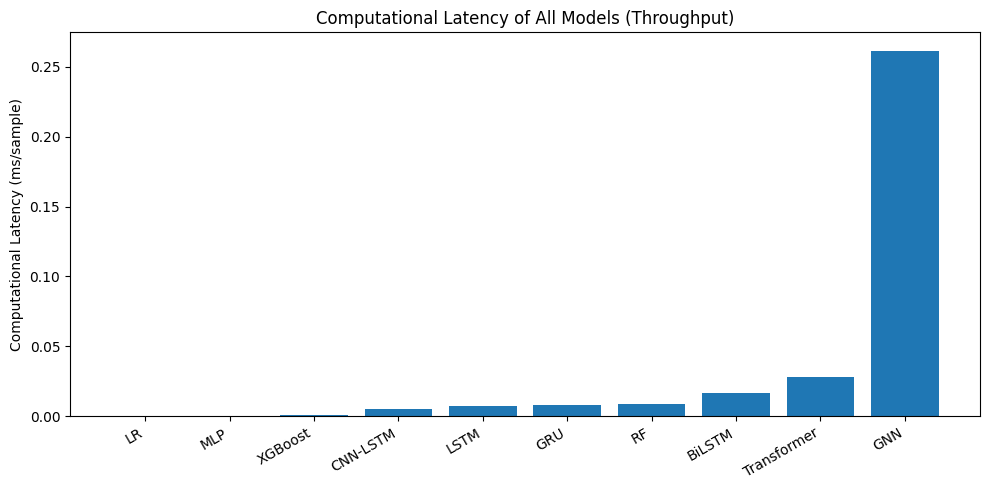

In [4]:
def plot_computational_latency(df, title):
    df_plot = df.copy()

    if "Computational Latency (ms/sample)" not in df_plot.columns:
        raise ValueError("Column 'Computational Latency (ms/sample)' not found.")

    df_plot = df_plot.sort_values("Computational Latency (ms/sample)", ascending=True)

    models = df_plot["Model"].tolist()
    latency = df_plot["Computational Latency (ms/sample)"].tolist()

    plt.figure(figsize=(10, 5))
    plt.bar(models, latency)
    plt.ylabel("Computational Latency (ms/sample)")
    plt.title(title)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

plot_computational_latency(
    computational_dfs["throughput"],
    "Computational Latency of All Models (Throughput)"
)

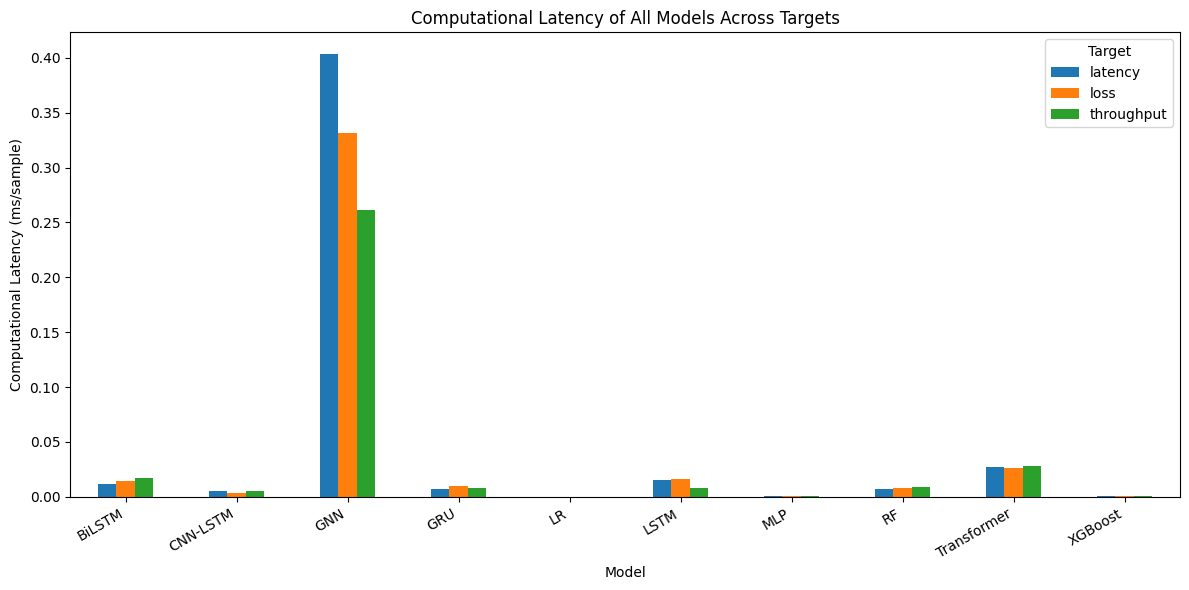

,Model,Model Size (MB),Computational Latency (ms/sample),Energy (J/sample),Num Parameters,Trees,Total Nodes,Average Nodes per Tree,Average Tree Depth,Max Tree Depth,Model Size (Bytes),Computational Latency (s/sample),Energy Estimated (J/sample),Peak Activation Memory (Bytes),Batch Size (Repeats),Parameters,Target
0,LR,0.001222,0.000098,1.968000e-07,74.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,throughput
1,RF,0.194703,0.008846,NaN,NaN,300.0,1500.0,5.000000,2.000000,2.0,204161.0,0.000009,0.000018,292.0,1000.0,NaN,throughput
2,XGBoost,0.187287,0.000963,1.925800e-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,throughput
3,MLP,0.082523,0.000505,1.010400e-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21633.0,throughput
4,LSTM,0.292240,0.007668,1.533600e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76609.0,throughput
5,GRU,0.197269,0.007802,1.560400e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51713.0,throughput
6,BiLSTM,0.650883,0.016804,3.360800e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170625.0,throughput
7,Transformer,1.549320,0.028036,5.607200e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,406145.0,throughput
8,CNN-LSTM,0.202885,0.005526,1.105240e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53185.0,throughput
9,GNN,0.004642,0.261416,1.307080e-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1217.0,throughput


Target,latency,loss,throughput
Model,,,
BiLSTM,0.012058,0.014884,0.016804
CNN-LSTM,0.004876,0.003606,0.005526
GNN,0.403044,0.331281,0.261416
GRU,0.007035,0.009847,0.007802
LR,0.000083,0.000094,0.000098
LSTM,0.015532,0.015924,0.007668
MLP,0.000492,0.000601,0.000505
RF,0.007573,0.008159,0.008846
Transformer,0.026782,0.025847,0.028036


In [5]:
def plot_all_computational_targets_side_by_side(dfs):
    records = []
    for metric_key, df in dfs.items():
        tmp = df.copy()
        tmp["Target"] = metric_key
        records.append(tmp)

    combined = pd.concat(records, ignore_index=True)

    pivot = combined.pivot_table(
        index="Model",
        columns="Target",
        values="Computational Latency (ms/sample)"
    )

    pivot = pivot.reindex(sorted(pivot.index))

    ax = pivot.plot(kind="bar", figsize=(12, 6))
    ax.set_ylabel("Computational Latency (ms/sample)")
    ax.set_title("Computational Latency of All Models Across Targets")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    return combined, pivot

combined_comp_df, pivot_comp_df = plot_all_computational_targets_side_by_side(computational_dfs)
display(combined_comp_df)
display(pivot_comp_df)

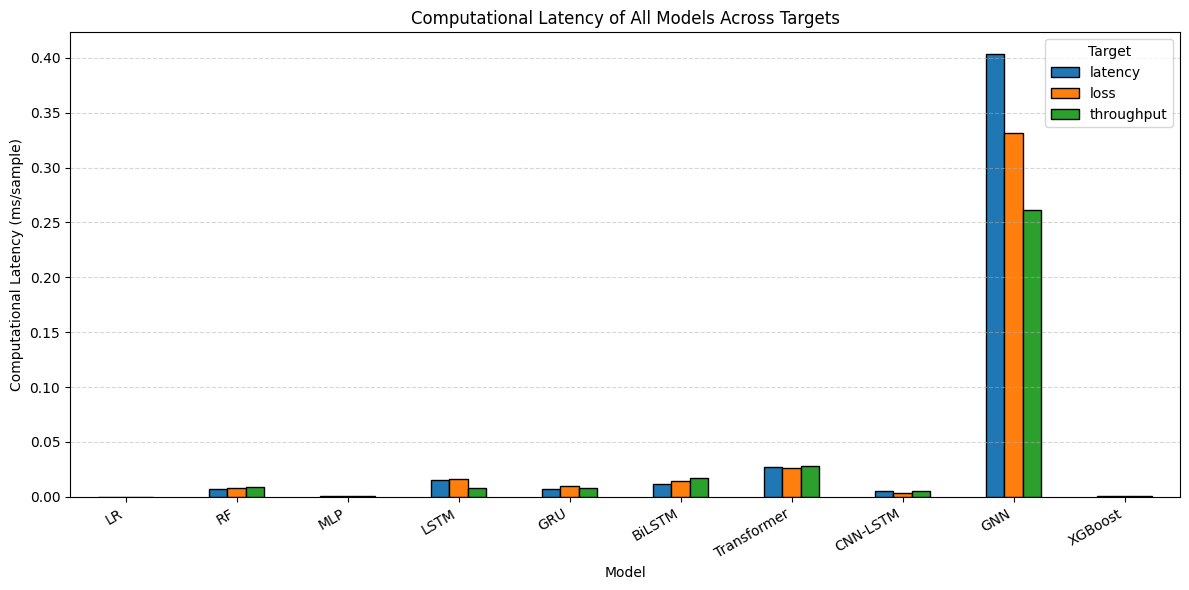

,Model,Model Size (MB),Computational Latency (ms/sample),Energy (J/sample),Num Parameters,Trees,Total Nodes,Average Nodes per Tree,Average Tree Depth,Max Tree Depth,Model Size (Bytes),Computational Latency (s/sample),Energy Estimated (J/sample),Peak Activation Memory (Bytes),Batch Size (Repeats),Parameters,Target
0,LR,0.001222,0.000098,1.968000e-07,74.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,throughput
1,RF,0.194703,0.008846,NaN,NaN,300.0,1500.0,5.000000,2.000000,2.0,204161.0,0.000009,0.000018,292.0,1000.0,NaN,throughput
2,XGBoost,0.187287,0.000963,1.925800e-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,throughput
3,MLP,0.082523,0.000505,1.010400e-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21633.0,throughput
4,LSTM,0.292240,0.007668,1.533600e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76609.0,throughput
5,GRU,0.197269,0.007802,1.560400e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51713.0,throughput
6,BiLSTM,0.650883,0.016804,3.360800e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170625.0,throughput
7,Transformer,1.549320,0.028036,5.607200e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,406145.0,throughput
8,CNN-LSTM,0.202885,0.005526,1.105240e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53185.0,throughput
9,GNN,0.004642,0.261416,1.307080e-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1217.0,throughput


Target,latency,loss,throughput
Model,,,
LR,0.000083,0.000094,0.000098
RF,0.007573,0.008159,0.008846
MLP,0.000492,0.000601,0.000505
LSTM,0.015532,0.015924,0.007668
GRU,0.007035,0.009847,0.007802
BiLSTM,0.012058,0.014884,0.016804
Transformer,0.026782,0.025847,0.028036
CNN-LSTM,0.004876,0.003606,0.005526
GNN,0.403044,0.331281,0.261416


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_all_computational_targets_side_by_side(dfs):
    records = []
    for metric_key, df in dfs.items():
        tmp = df.copy()
        tmp["Target"] = metric_key
        records.append(tmp)

    combined = pd.concat(records, ignore_index=True)

    pivot = combined.pivot_table(
        index="Model",
        columns="Target",
        values="Computational Latency (ms/sample)"
    )

    # match edge plot order
    desired_order = [
        "LR", "RF", "MLP", "LSTM", "GRU",
        "BiLSTM", "Transformer", "CNN-LSTM", "GNN", "XGBoost"
    ]

    existing_order = [m for m in desired_order if m in pivot.index]
    remaining = [m for m in pivot.index if m not in existing_order]
    pivot = pivot.reindex(existing_order + remaining)

    ax = pivot.plot(
        kind="bar",
        figsize=(12, 6),
        edgecolor="black"
    )
    ax.set_ylabel("Computational Latency (ms/sample)")
    ax.set_xlabel("Model")
    ax.set_title("Computational Latency of All Models Across Targets")
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig("compare_all_targets_computational_latency.png", dpi=300, bbox_inches="tight")
    plt.show()
  

    return combined, pivot

combined_comp_df, pivot_comp_df = plot_all_computational_targets_side_by_side(computational_dfs)
display(combined_comp_df)
display(pivot_comp_df)

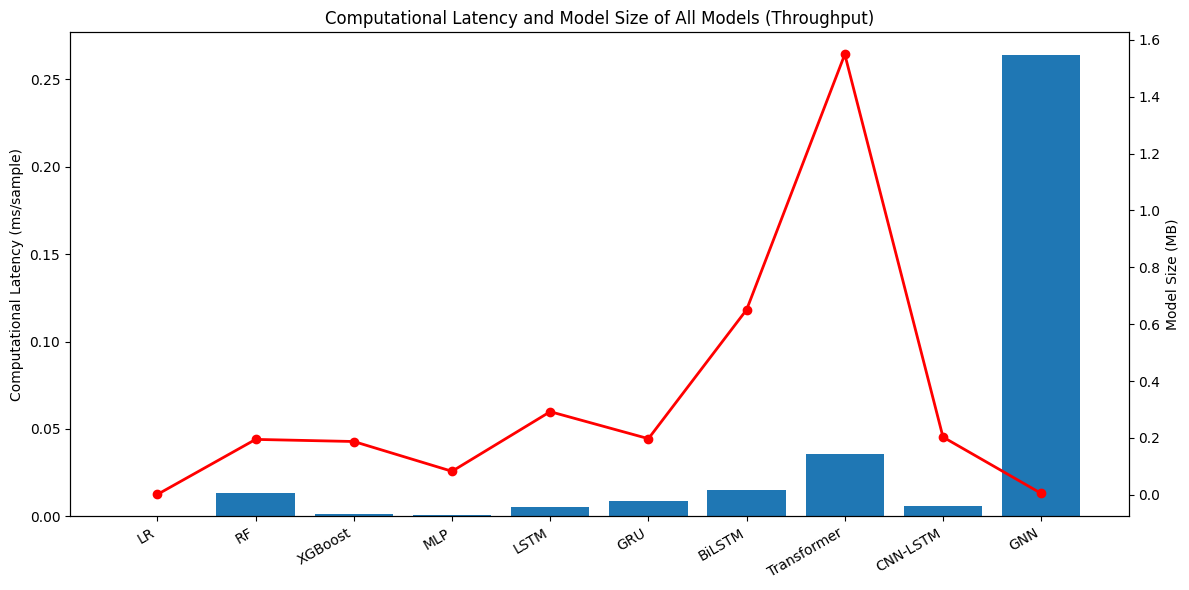

In [9]:
def plot_computational_bar_line(df, title):
    df_plot = df.copy()

    latency_col = "Computational Latency (ms/sample)"
    size_col = "Model Size (MB)"

    if latency_col not in df_plot.columns:
        raise ValueError(f"Column '{latency_col}' not found.")
    if size_col not in df_plot.columns:
        raise ValueError(f"Column '{size_col}' not found.")

    models = df_plot["Model"].tolist()
    latency = df_plot[latency_col].tolist()
    size = df_plot[size_col].tolist()

    x = np.arange(len(models))

    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.bar(x, latency)
    ax1.set_ylabel("Computational Latency (ms/sample)")
    ax1.set_xticks(x)
    ax1.set_xticklabels(models, rotation=30, ha="right")

    ax2 = ax1.twinx()
    ax2.plot(x, size, marker="o", color="red", linewidth=2)
    ax2.set_ylabel("Model Size (MB)")

    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_computational_bar_line(
    computational_dfs["throughput"],
    "Computational Latency and Model Size of All Models (Throughput)"
)

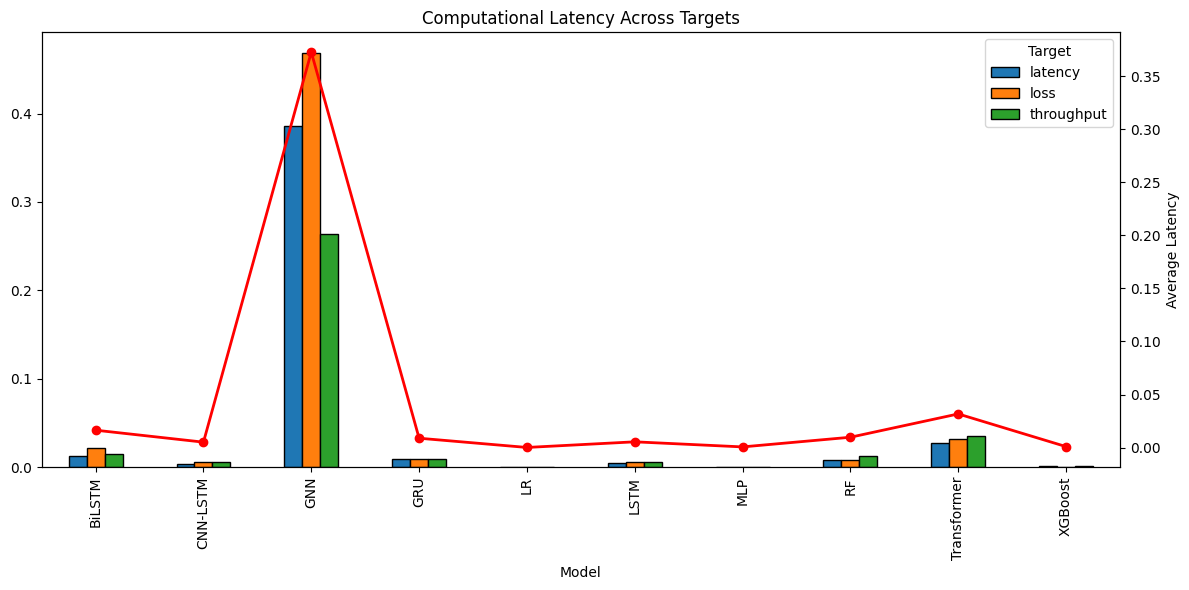

In [27]:
def plot_multi_target_bar_line(dfs):
    import pandas as pd

    combined = []
    for k, df in dfs.items():
        tmp = df.copy()
        tmp["Target"] = k
        combined.append(tmp)

    combined = pd.concat(combined)

    pivot = combined.pivot_table(
        index="Model",
        columns="Target",
        values="Computational Latency (ms/sample)"
    )

    pivot = pivot.reindex(sorted(pivot.index))

    ax = pivot.plot(
        kind="bar",
        figsize=(12,6),
        edgecolor="black"
    )

    # Add average latency as red line
    avg_latency = pivot.mean(axis=1)

    ax2 = ax.twinx()
    ax2.plot(
        np.arange(len(avg_latency)),
        avg_latency,
        color="red",
        marker="o",
        linewidth=2
    )
    ax2.set_ylabel("Average Latency")

    plt.title("Computational Latency Across Targets")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

plot_multi_target_bar_line(computational_dfs)